# **1. Introduction et description du Dataset**




# **2. Importation des librairies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.patches as mpatches

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

# **3. Chargement des données**

In [ ]:

print(' *** Chargement et inspection initiale ***')
  #chargement du dataset
df = pd.read_csv('medical-charges.csv')
print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')

  #Aperçu des premières et dernières lignes
print('*** Premières lignes ***')
display(df.head())

print('\n*** Dernières lignes ***')
display(df.tail())

  #Informations structurelles
print(f'Dimensions : {df.shape}\n')
print('\n*** Informations  ***')
df.info()

  #Statistiques descriptives
print('\n*** Statistiques descriptives ***')
display(df.describe(include='all').T)

  #Vérification des valeurs manquantes et doublons
print('\n*** Vérification des valeurs manquantes et doublons ***')
    # Valeurs manquantes
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing)

   #Doublons
n_dup = df.duplicated().sum()
print(f'\n Nombre de doublons : {n_dup}')
if n_dup > 0:
    print('Doublons detectés')
    display(df[df.duplicated()])
else:
    print('Aucun doublon')

  #Vérification des types de données
print('\n*** Vérification des types de données ***')
type_summary = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs uniques': df.nunique(),
    'Exemple': df.iloc[0]
})
display(type_summary)



 *** Chargement et inspection initiale ***
Dataset chargé : 1338 lignes × 7 colonnes
*** Premières lignes ***


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



*** Dernières lignes ***


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


Dimensions : (1338, 7)


*** Informations  ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

*** Statistiques descriptives ***


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



*** Vérification des valeurs manquantes et doublons ***
Valeurs manquantes par colonne :
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 Nombre de doublons : 1
Doublons detectés


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



*** Vérification des types de données ***


,Type,Valeurs uniques,Exemple
age,int64,47,19
sex,object,2,female
bmi,float64,548,27.9
children,int64,6,0
smoker,object,2,yes
region,object,4,southwest
charges,float64,1337,16884.924


# **4. Phase 1 — Analyse Exploratoire des Données (EDA)**


*** Analyse Univariée ***
Distribution des variables numériques via histogrammes


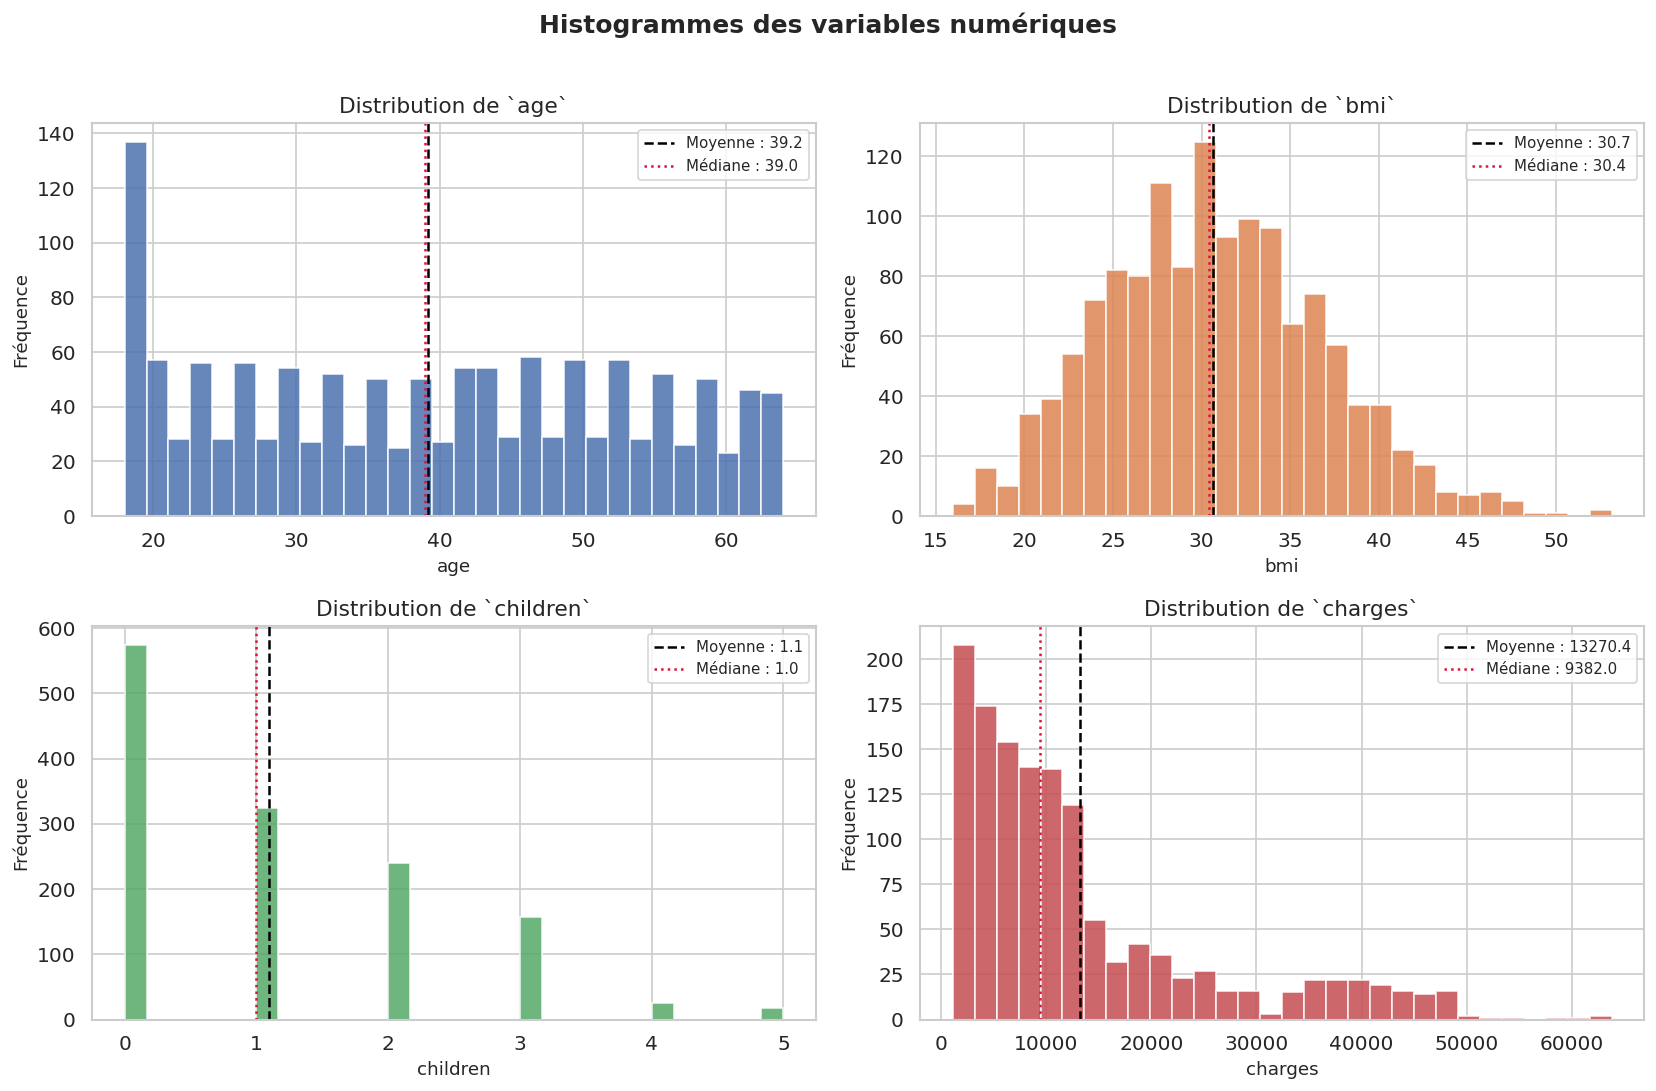


Distribution des variables numériques via boxplots


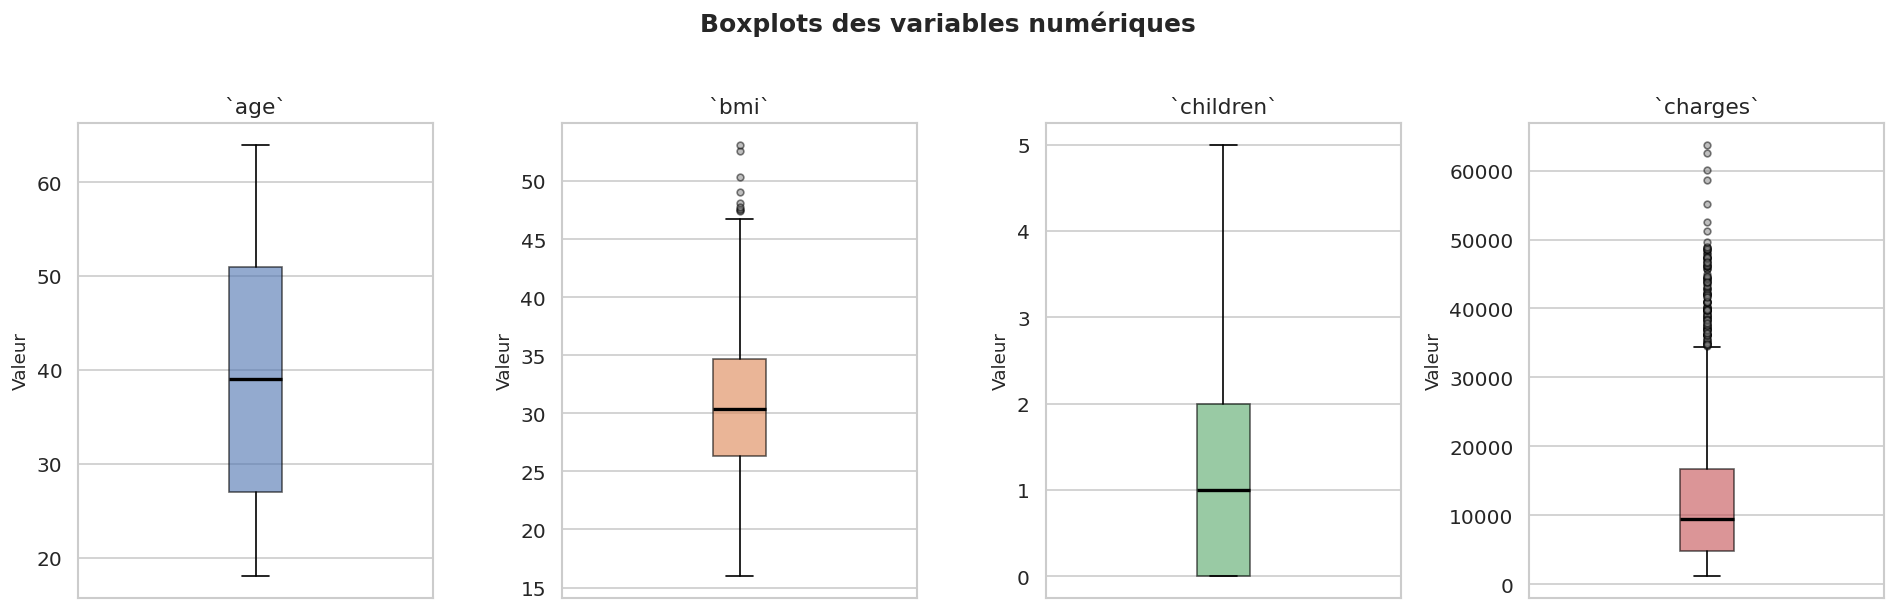


Distribution des variables catégorielles via Countplots


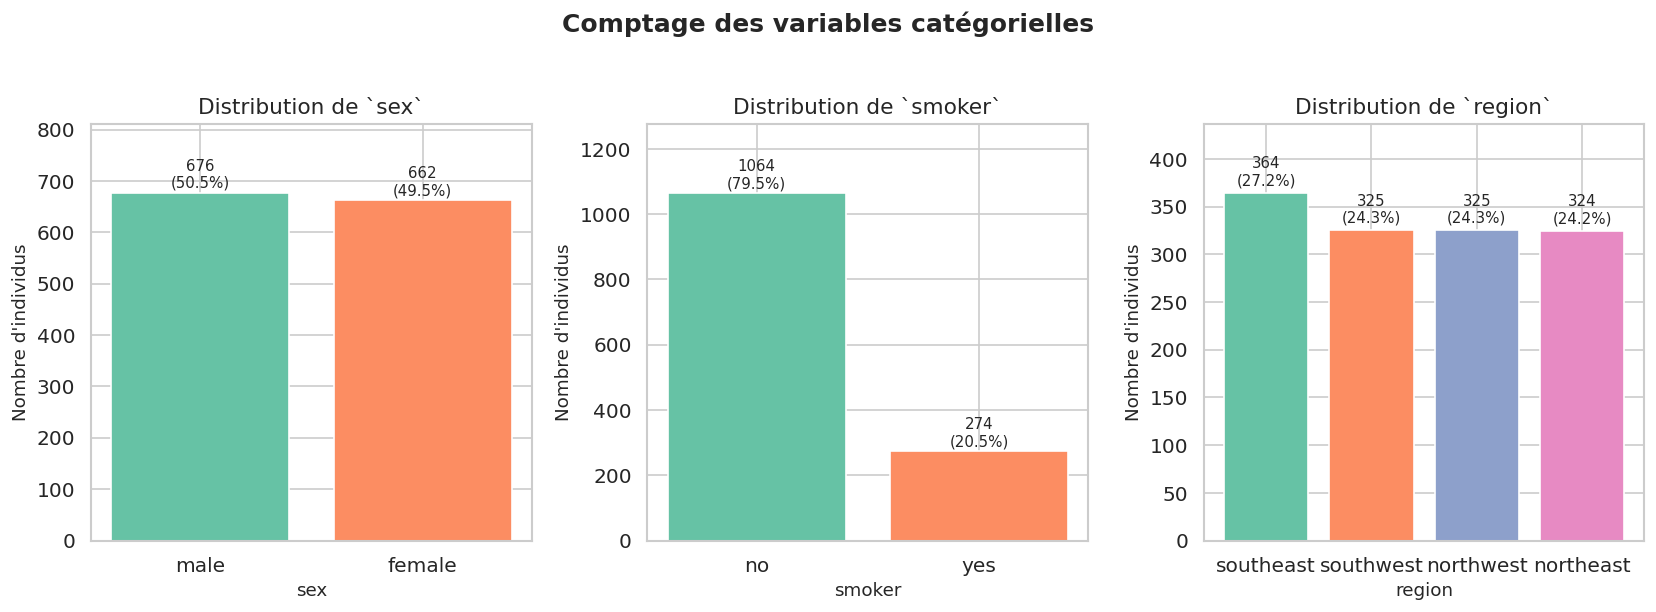


Charges vs variables numériques — Scatter plots


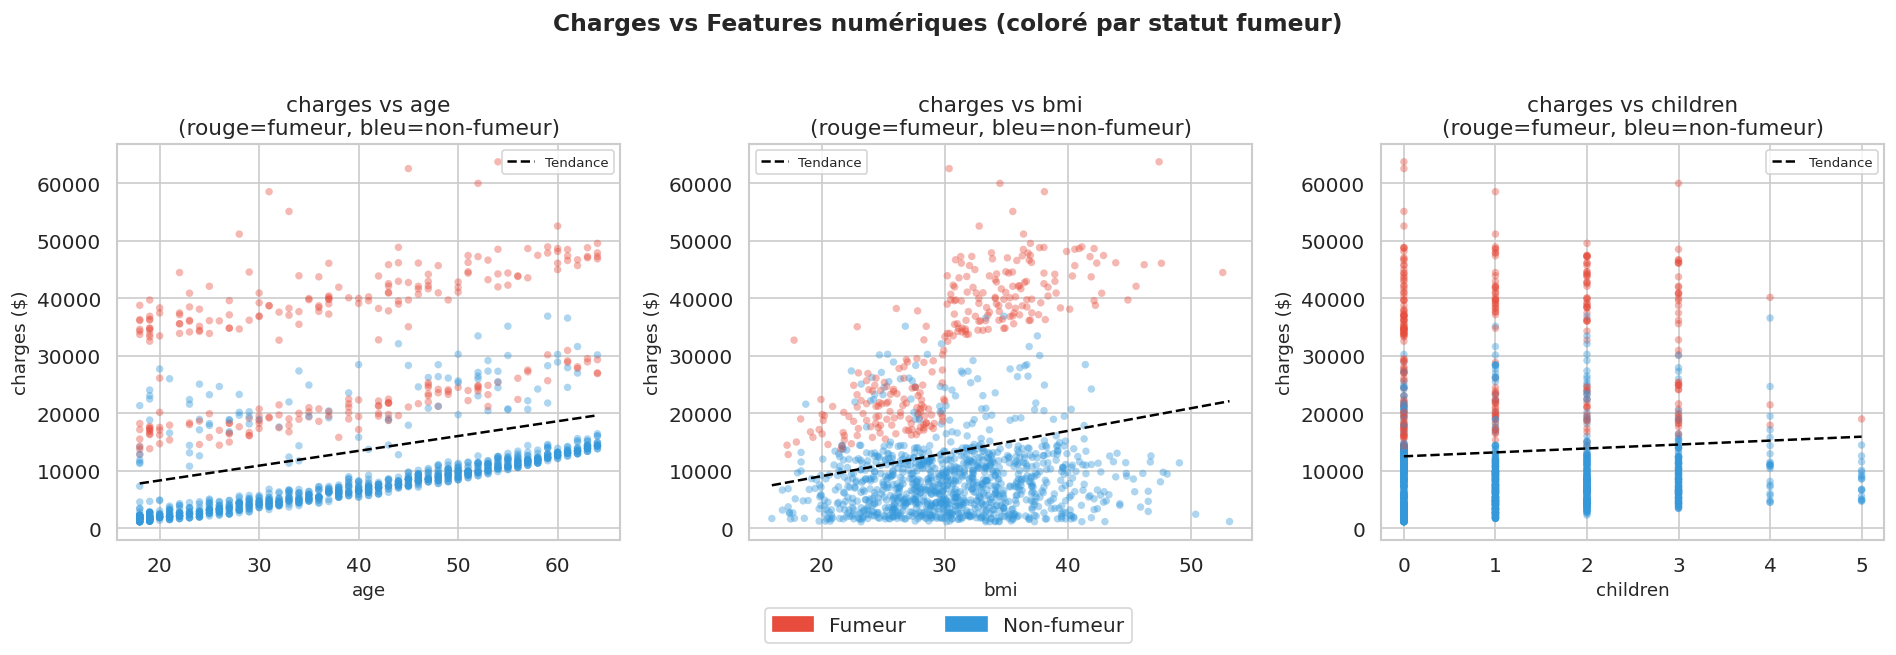


Charges vs variables catégorielles — Boxplots


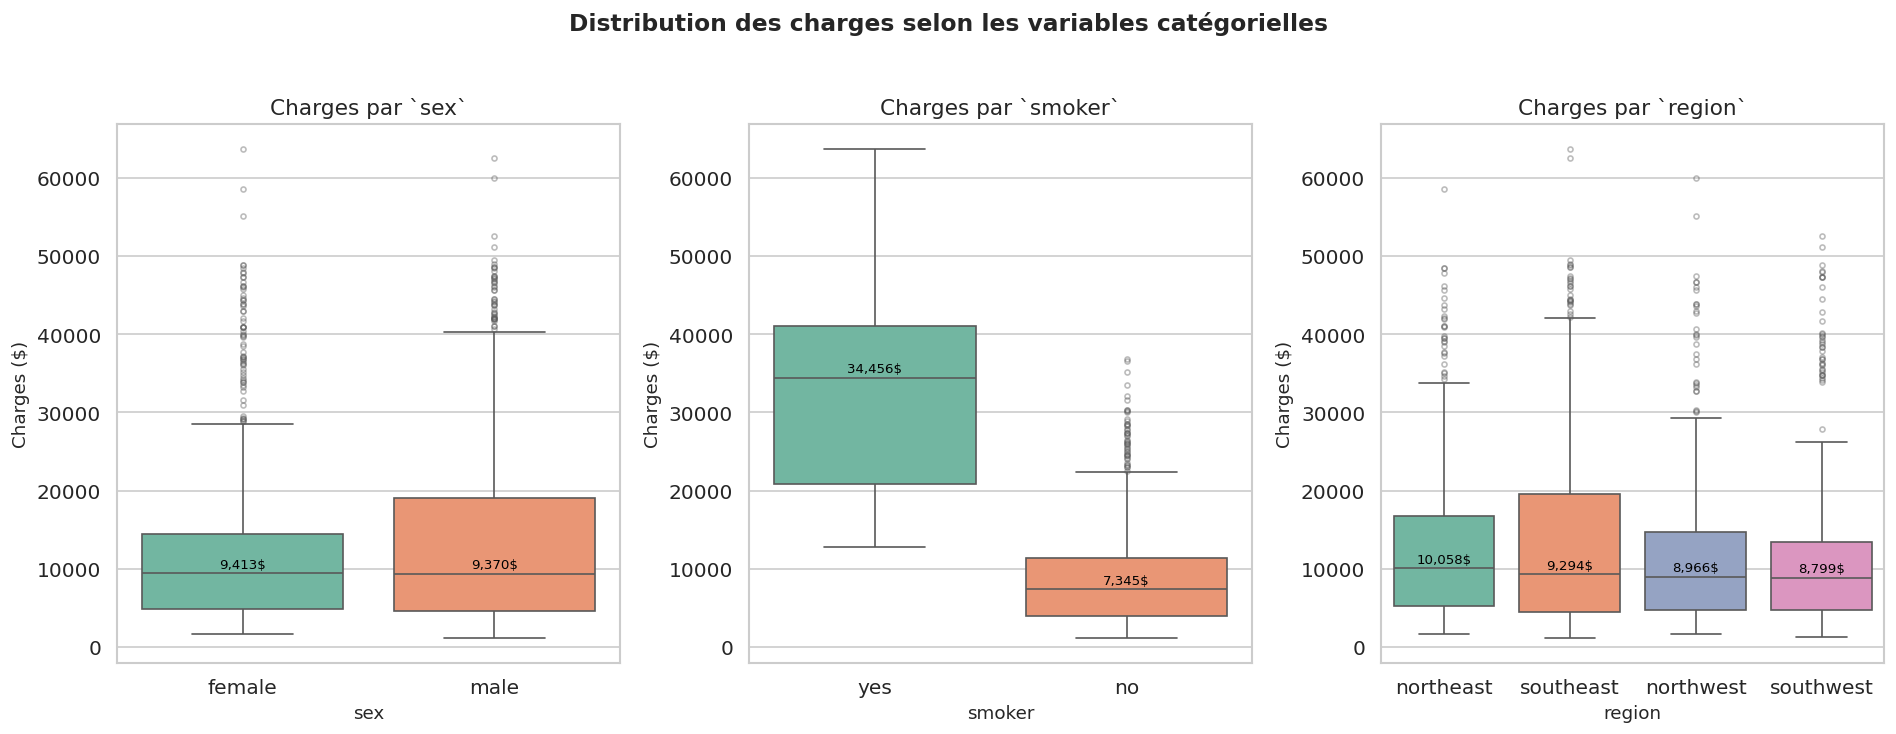


Impact du statut fumeur sur les charges


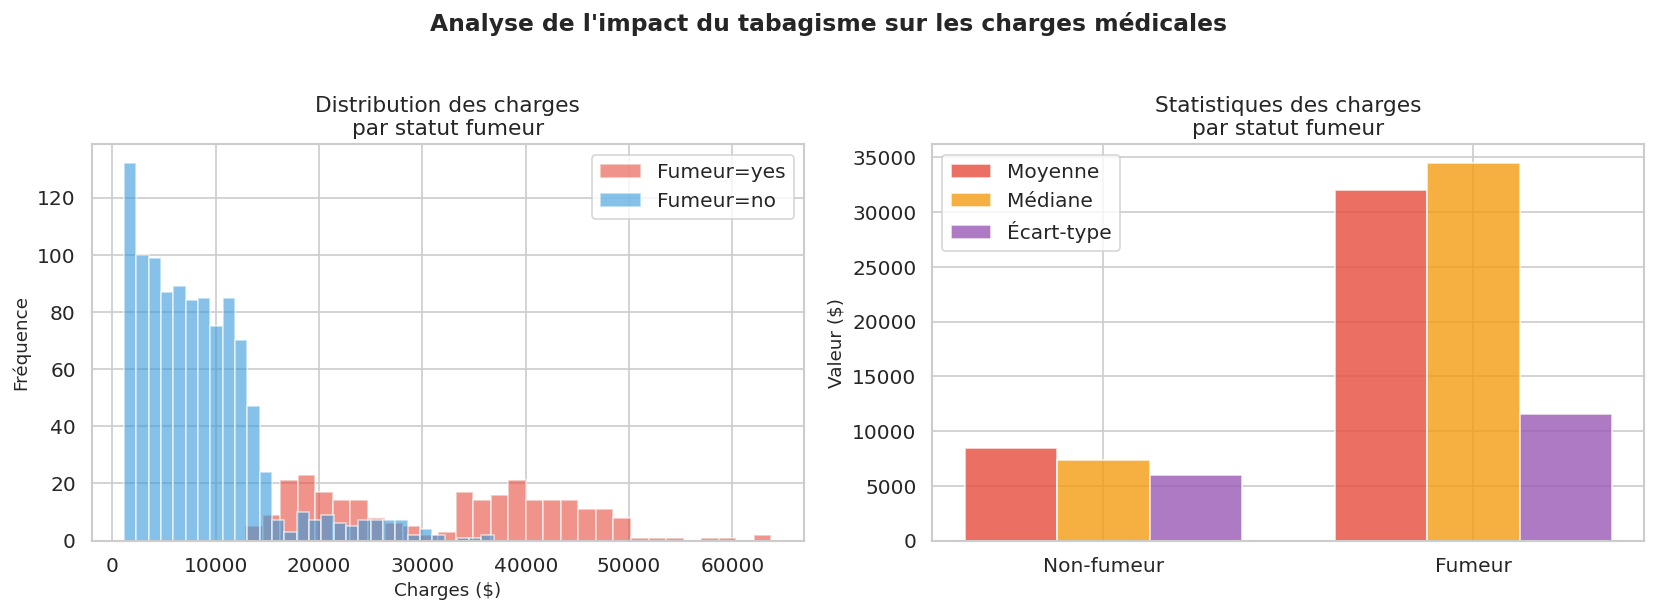


── Statistiques détaillées des charges par statut fumeur ──


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801



Les fumeurs paient en moyenne 3.8x plus de charges que les non-fumeurs.

Interaction BMI × Statut Fumeur sur les charges


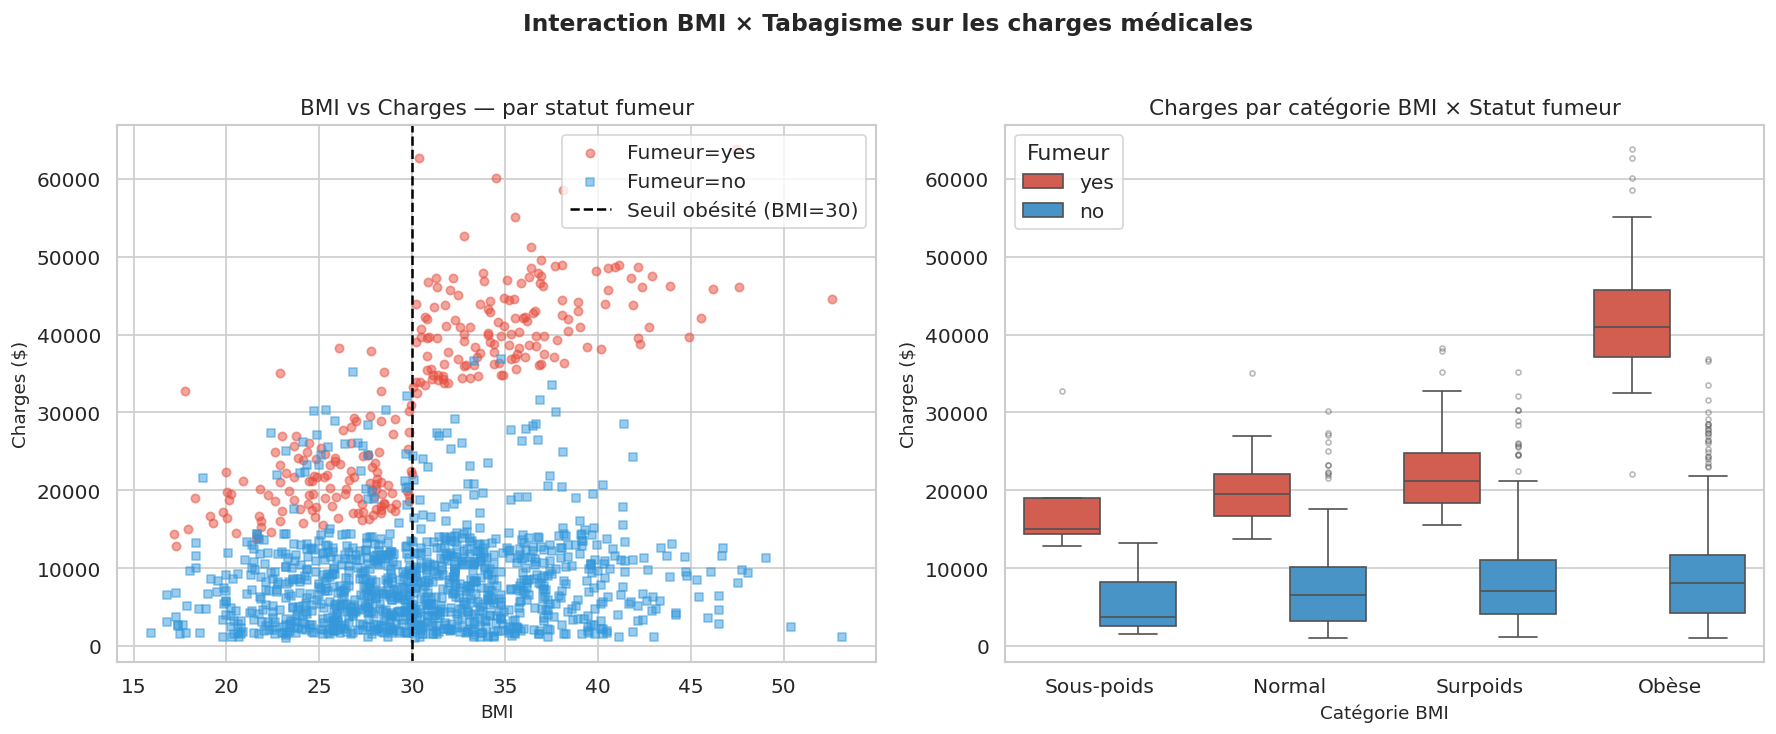


Matrice de corrélation


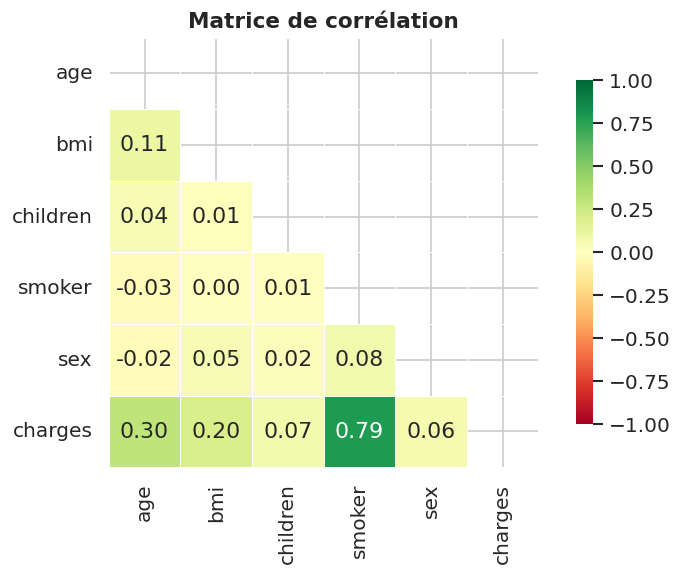


Pairplot coloré par statut fumeur


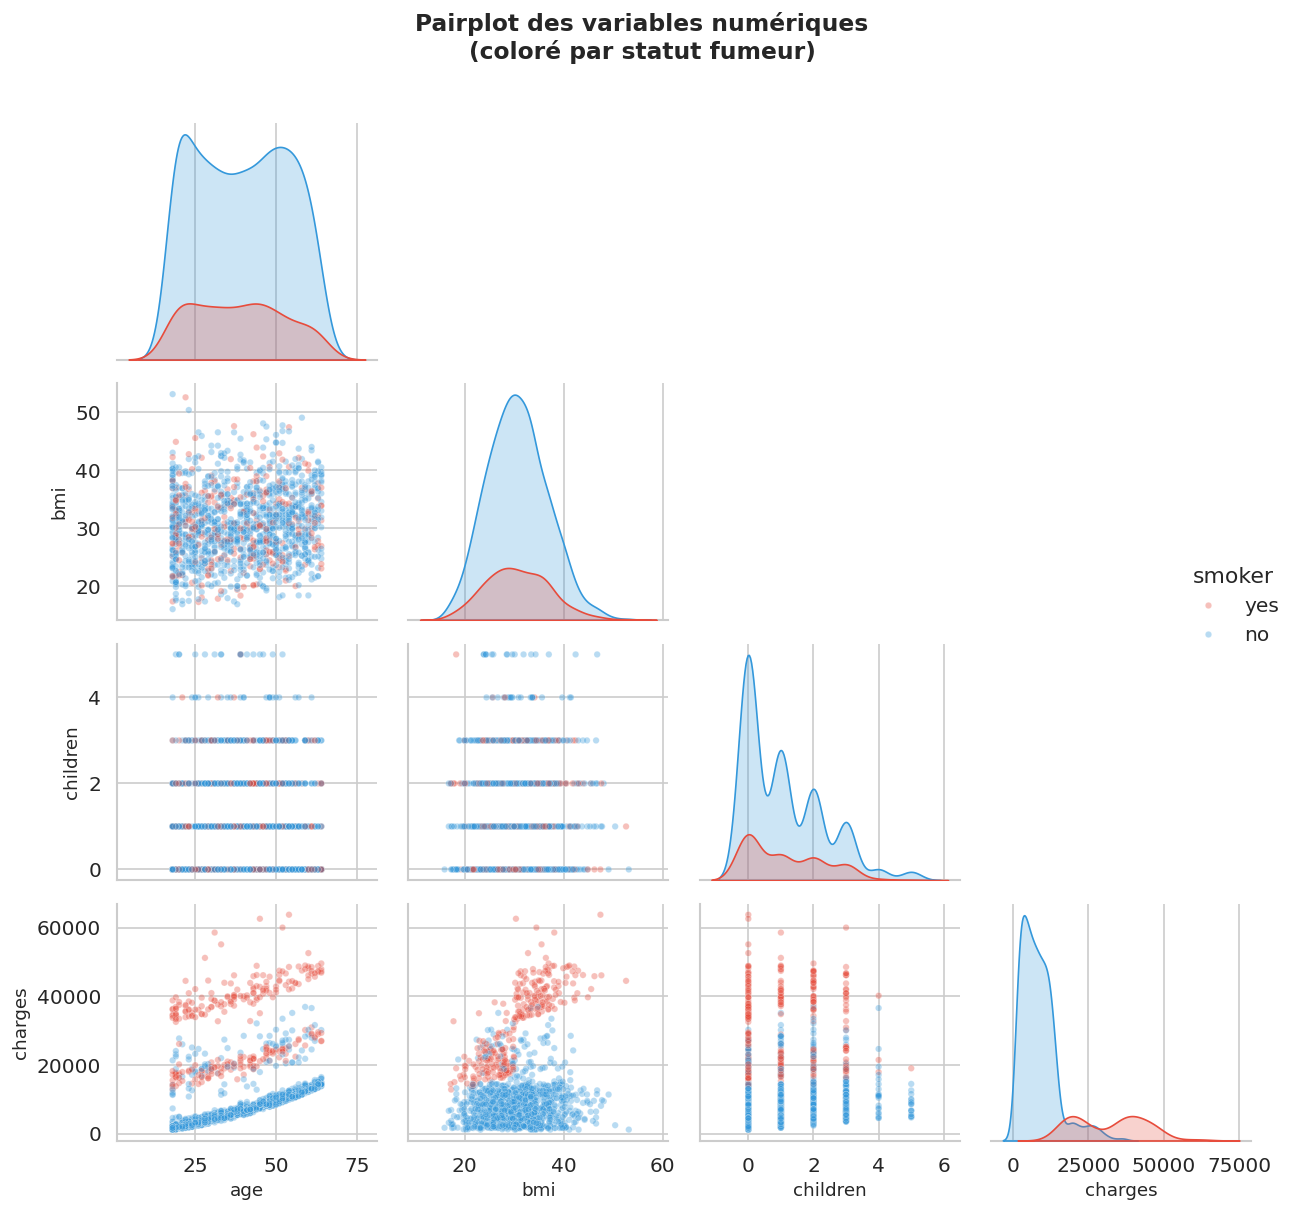


Méthode IQR — Calcul des seuils
Variable     |         Q1 |         Q3 |        IQR |    Borne Inf |    Borne Sup | # Outliers
--------------------------------------------------------------------------------------------
age          |      27.00 |      51.00 |      24.00 |        -9.00 |        87.00 |          0
bmi          |      26.30 |      34.69 |       8.40 |        13.70 |        47.29 |          9
children     |       0.00 |       2.00 |       2.00 |        -3.00 |         5.00 |          0
charges      |    4740.29 |   16639.91 |   11899.63 |    -13109.15 |     34489.35 |        139

 Visualisation des outliers — Boxplots annotés


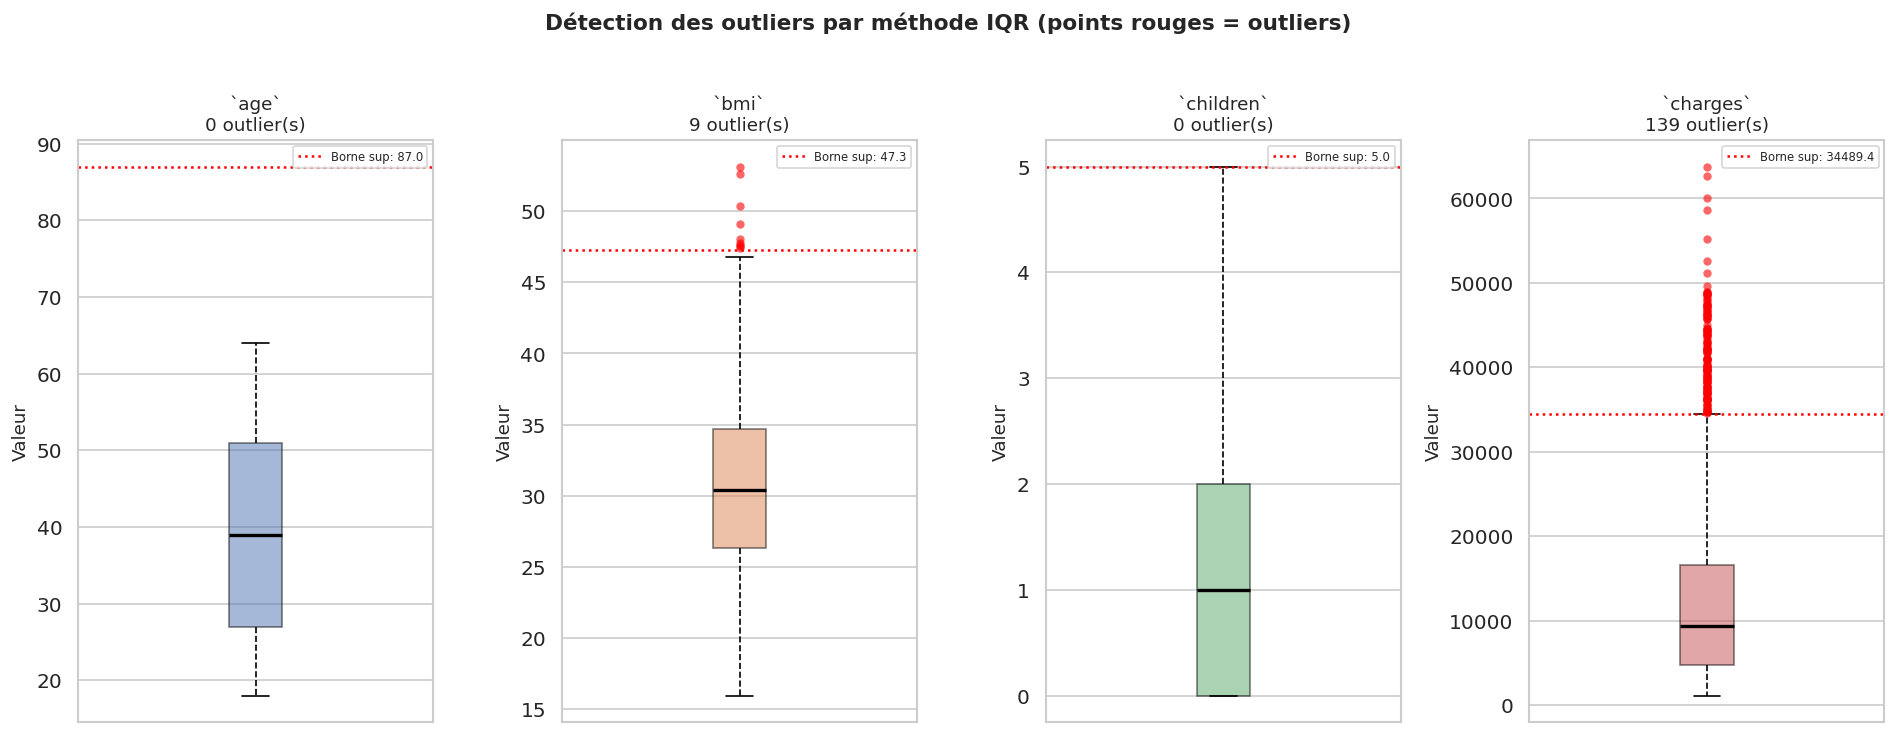


 Analyse détaillée des outliers de charges
Nombre d'outliers dans `charges` : 139
Borne supérieure IQR             : 34,489.35 $
Valeur max observée              : 63,770.43 $
Proportion d'outliers            : 10.4%

── Profil des outliers de charges ──


,age,bmi,children,charges
count,139.000000,139.000000,139.000000,139.000000
mean,41.079137,35.564604,1.187050,42103.947206
std,13.801420,4.434917,1.126546,5582.168107
min,18.000000,22.895000,0.000000,34617.840650
25%,30.000000,32.667500,0.000000,37786.149950
50%,43.000000,35.200000,1.000000,40974.164900
75%,52.500000,37.660000,2.000000,45786.706425
max,64.000000,52.580000,4.000000,63770.428010



── Statut fumeur parmi les outliers de charges ──
smoker
yes    136
no       3
Name: count, dtype: int64

 97.8% des outliers de charges sont des fumeurs.


In [ ]:

#4.1. Analyse Univariée
  #Distribution des variables numériques via Histogrammes
print('\n*** Analyse Univariée ***')
print('Distribution des variables numériques via histogrammes')

num_cols = ['age', 'bmi', 'children', 'charges']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Moyenne : {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='crimson', linestyle=':',  linewidth=1.5, label=f'Médiane : {df[col].median():.1f}')
    axes[i].set_title(f'Distribution de `{col}`')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=9)

plt.suptitle('Histogrammes des variables numériques', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  #Distribution des variables numériques via boxplots
print('\nDistribution des variables numériques via boxplots')
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )
    axes[i].set_title(f'`{col}`')
    axes[i].set_ylabel('Valeur')
    axes[i].set_xticks([])

plt.suptitle('Boxplots des variables numériques', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


  #Distribution des variables catégorielles via Countplots
print('\nDistribution des variables catégorielles via Countplots')
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('Set2', len(counts)),
                       edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h + 5,
                     f'{int(h)}\n({h/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)
    axes[i].set_title(f'Distribution de `{col}`')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre d'individus")
    axes[i].set_ylim(0, counts.max() * 1.2)

plt.suptitle('Comptage des variables catégorielles', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#4.2. Analyse bivariée :
  #Charges vs variables numériques — Scatter plots
print('\nCharges vs variables numériques — Scatter plots')
features_num = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

smoker_colors = df['smoker'].map({'yes': '#E74C3C', 'no': '#3498DB'})

for i, col in enumerate(features_num):
    axes[i].scatter(df[col], df['charges'], c=smoker_colors, alpha=0.4, s=20, edgecolors='none')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('charges ($)', fontsize=11)
    axes[i].set_title(f'charges vs {col}\n(rouge=fumeur, bleu=non-fumeur)')

    m, b = np.polyfit(df[col], df['charges'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='black', linestyle='--', linewidth=1.5, label='Tendance')
    axes[i].legend(fontsize=8)

legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Fumeur'),
    mpatches.Patch(color='#3498DB', label='Non-fumeur')
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Charges vs Features numériques (coloré par statut fumeur)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

  #Charges vs variables catégorielles — Boxplots
print('\nCharges vs variables catégorielles — Boxplots')
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df, x=col, y='charges',
        order=order,
        palette='Set2',
        ax=axes[i],
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    for j, cat in enumerate(order):
        med = df[df[col]==cat]['charges'].median()
        axes[i].text(j, med + 300, f'{med:,.0f}$', ha='center', va='bottom', fontsize=8, color='black')

    axes[i].set_title(f'Charges par `{col}`')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Charges ($)')

plt.suptitle('Distribution des charges selon les variables catégorielles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

  #Impact du statut fumeur sur les charges
print('\nImpact du statut fumeur sur les charges')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, color in [('yes', '#E74C3C'), ('no', '#3498DB')]:
    axes[0].hist(df[df['smoker']==status]['charges'],
                 bins=30, color=color, alpha=0.6, label=f'Fumeur={status}', edgecolor='white')
axes[0].set_title('Distribution des charges\npar statut fumeur')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

stats = df.groupby('smoker')['charges'].agg(['mean', 'median', 'std']).reset_index()
x = np.arange(len(stats))
width = 0.25
axes[1].bar(x - width, stats['mean'],   width, label='Moyenne',    color='#E74C3C', alpha=0.8)
axes[1].bar(x,          stats['median'], width, label='Médiane',    color='#F39C12', alpha=0.8)
axes[1].bar(x + width,  stats['std'],    width, label='Écart-type', color='#9B59B6', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Non-fumeur', 'Fumeur'])
axes[1].set_title('Statistiques des charges\npar statut fumeur')
axes[1].set_ylabel('Valeur ($)')
axes[1].legend()

plt.suptitle("Analyse de l'impact du tabagisme sur les charges médicales",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n── Statistiques détaillées des charges par statut fumeur ──')
display(df.groupby('smoker')['charges'].describe())

ratio = df[df['smoker']=='yes']['charges'].mean() / df[df['smoker']=='no']['charges'].mean()
print(f'\nLes fumeurs paient en moyenne {ratio:.1f}x plus de charges que les non-fumeurs.')

  #Interaction BMI × Statut Fumeur sur les charges
print('\nInteraction BMI × Statut Fumeur sur les charges')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for status, color, marker in [('yes', '#E74C3C', 'o'), ('no', '#3498DB', 's')]:
    subset = df[df['smoker'] == status]
    axes[0].scatter(subset['bmi'], subset['charges'],
                    c=color, alpha=0.5, s=25, marker=marker, label=f'Fumeur={status}')

axes[0].axvline(30, color='black', linestyle='--', linewidth=1.5, label='Seuil obésité (BMI=30)')
axes[0].set_title('BMI vs Charges — par statut fumeur')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges ($)')
axes[0].legend()

def bmi_category(bmi):
    if bmi < 18.5: return 'Sous-poids'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Surpoids'
    else:           return 'Obèse'

df['bmi_cat'] = df['bmi'].apply(bmi_category)
bmi_order = ['Sous-poids', 'Normal', 'Surpoids', 'Obèse']

sns.boxplot(
    data=df, x='bmi_cat', y='charges', hue='smoker',
    order=bmi_order, palette={'yes': '#E74C3C', 'no': '#3498DB'},
    ax=axes[1],
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
axes[1].set_title('Charges par catégorie BMI × Statut fumeur')
axes[1].set_xlabel('Catégorie BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].legend(title='Fumeur', loc='upper left')

plt.suptitle('Interaction BMI × Tabagisme sur les charges médicales',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df.drop(columns=['bmi_cat'], inplace=True)

#4.3. Analyse multivariée
    #Matrice de corrélation
print('\nMatrice de corrélation')
df_corr = df.copy()
df_corr['smoker_enc'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex_enc']    = (df_corr['sex'] == 'male').astype(int)

corr_cols = ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges']
corr_matrix = df_corr[corr_cols].corr()

corr_matrix.columns = ['age', 'bmi', 'children', 'smoker', 'sex', 'charges']
corr_matrix.index   = ['age', 'bmi', 'children', 'smoker', 'sex', 'charges']

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
    #Pairplot coloré par statut fumeur
print('\nPairplot coloré par statut fumeur')
pairplot_cols = ['age', 'bmi', 'children', 'charges', 'smoker']

g = sns.pairplot(
    df[pairplot_cols],
    hue='smoker',
    palette={'yes': '#E74C3C', 'no': '#3498DB'},
    plot_kws={'alpha': 0.35, 's': 15},
    diag_kind='kde',
    corner=True
)

g.figure.suptitle('Pairplot des variables numériques\n(coloré par statut fumeur)',
                   fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#4.4. Détection des Outliers
    #Méthode IQR — Calcul des seuils
print('\nMéthode IQR — Calcul des seuils')
print('=' * 92)
print(f'{"Variable":12s} | {"Q1":>10s} | {"Q3":>10s} | {"IQR":>10s} | {"Borne Inf":>12s} | {"Borne Sup":>12s} | {"# Outliers":>10s}')
print('-' * 92)

outlier_report = {}

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_out = len(outliers)
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'lower': lower, 'upper': upper,
                           'n_outliers': n_out, 'outliers': outliers}

    print(f'{col:12s} | {Q1:>10.2f} | {Q3:>10.2f} | {IQR:>10.2f} | {lower:>12.2f} | {upper:>12.2f} | {n_out:>10d}')

print('=' * 92)

    # Visualisation des outliers — Boxplots annotés
print('\n Visualisation des outliers — Boxplots annotés')
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for i, (col, color) in enumerate(zip(num_cols, colors)):
    rep = outlier_report[col]

    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='red',
                        markersize=5, alpha=0.6, markeredgecolor='none'),
        whiskerprops=dict(linestyle='--')
    )

    axes[i].axhline(rep['upper'], color='red',   linestyle=':', linewidth=1.5,
                    label=f'Borne sup: {rep["upper"]:.1f}')
    if rep['lower'] > df[col].min():
        axes[i].axhline(rep['lower'], color='orange', linestyle=':', linewidth=1.5,
                        label=f'Borne inf: {rep["lower"]:.1f}')

    axes[i].set_title(f'`{col}`\n{rep["n_outliers"]} outlier(s)', fontsize=11)
    axes[i].set_xticks([])
    axes[i].set_ylabel('Valeur')
    axes[i].legend(fontsize=7, loc='upper right')

plt.suptitle('Détection des outliers par méthode IQR (points rouges = outliers)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

    #Analyse détaillée des outliers de charges
print('\n Analyse détaillée des outliers de charges')
charges_outliers = outlier_report['charges']['outliers']

print(f"Nombre d'outliers dans `charges` : {len(charges_outliers)}")
print(f"Borne supérieure IQR             : {outlier_report['charges']['upper']:,.2f} $")
print(f"Valeur max observée              : {df['charges'].max():,.2f} $")
print(f"Proportion d'outliers            : {len(charges_outliers)/len(df)*100:.1f}%")

print('\n── Profil des outliers de charges ──')
display(charges_outliers.describe())

print('\n── Statut fumeur parmi les outliers de charges ──')
print(charges_outliers['smoker'].value_counts())
pct_smoker_out = charges_outliers['smoker'].value_counts(normalize=True)['yes'] * 100
print(f'\n {pct_smoker_out:.1f}% des outliers de charges sont des fumeurs.')





# **5. Phase 2 — Nettoyage et Prétraitement (Cleaning & Preprocessing)**


Nombre de doublons détectés : 1

Aperçu des lignes dupliquées :


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



 Doublons supprimés. Nouvelle dimension du dataset : (1337, 7)
sex      : {'female': np.int64(0), 'male': np.int64(1)}
smoker   : {'no': np.int64(0), 'yes': np.int64(1)}
region   : One-Hot Encoding → colonnes créées : ['region_northwest', 'region_southeast', 'region_southwest']

 drop_first=True → on supprime une modalité de référence (region_northeast) pour éviter la multicolinéarité parfaite.

 Encodage terminé. Nouvelles colonnes du dataset :
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']
=== Statistiques après StandardScaler ===
             age        bmi   children
count  1337.0000  1337.0000  1337.0000
mean     -0.0000    -0.0000     0.0000
std       1.0004     1.0004     1.0004
min      -1.5116    -2.4111    -0.9092
25%      -0.8706    -0.7172    -0.9092
50%      -0.0158    -0.0432    -0.0794
75%       0.8389     0.6619     0.7504
max       1.7649     3.6841     3.2397

 Standardisation appliquée sur : ['age',

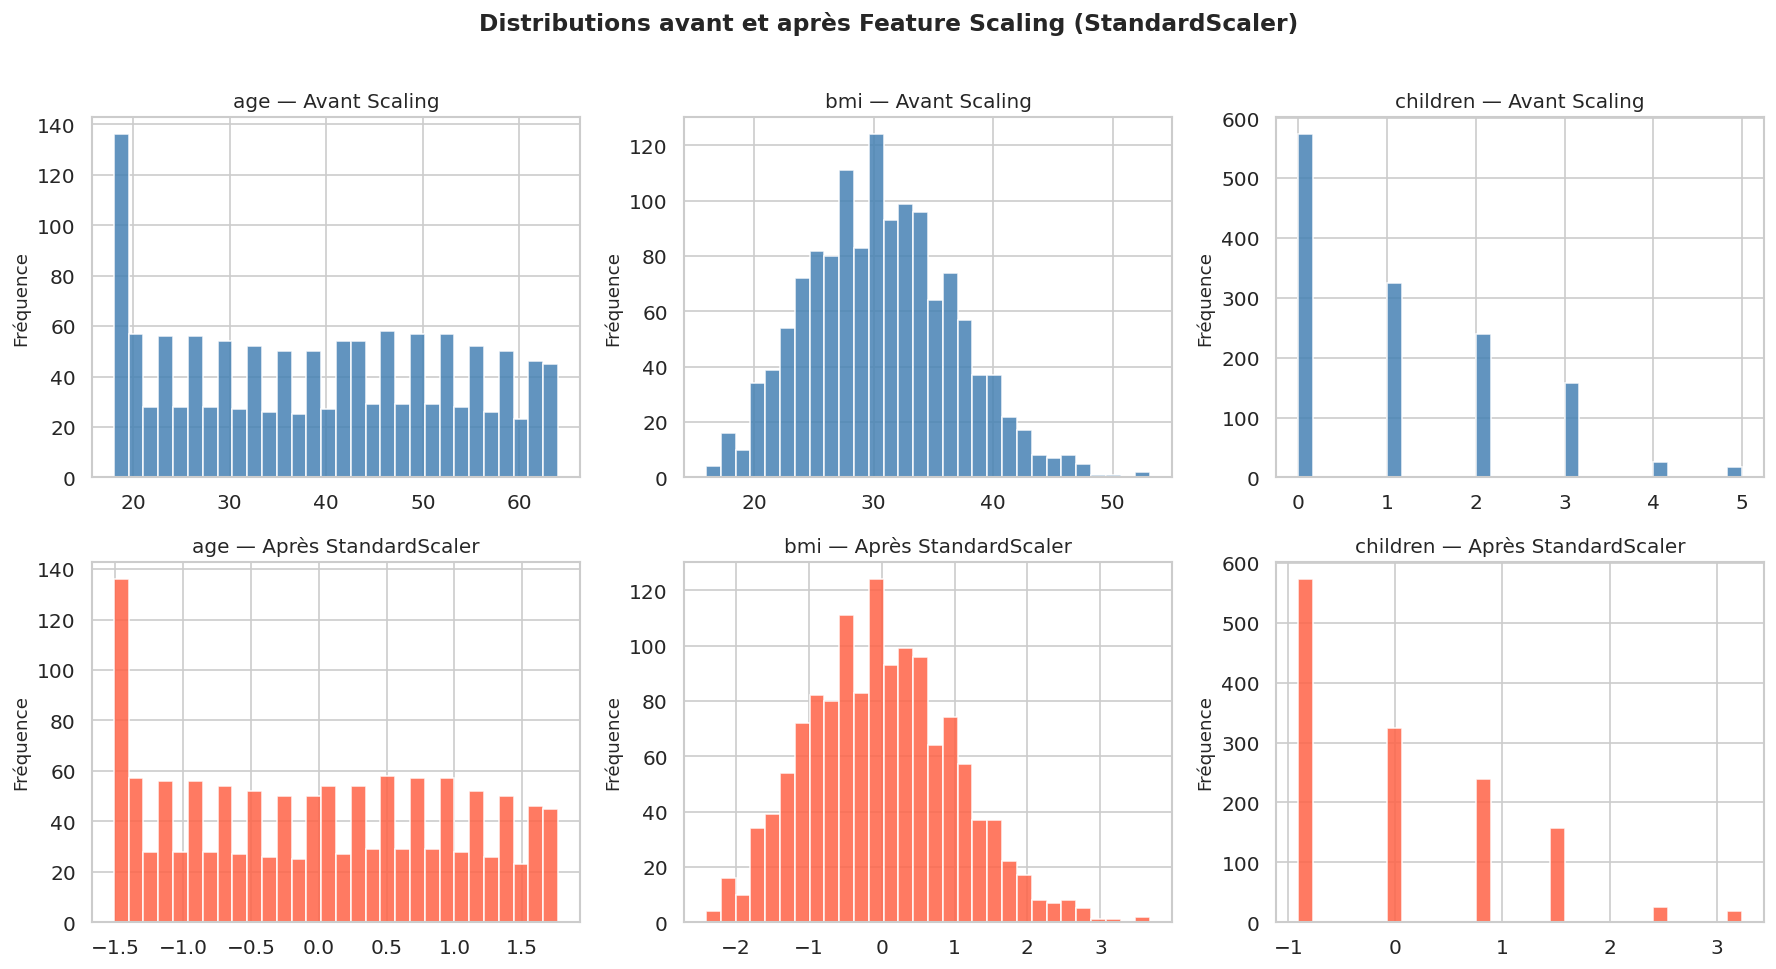

Graphique sauvegardé : phase2_scaling.png
Features (X) : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Cible    (y) : charges

Dimension X : (1337, 8)
Dimension y : (1337,)
=== Résumé du Split Train / Test ===
  Jeu d'entraînement  (X_train) : 1069 observations (80.0 %)
  Jeu de test         (X_test)  : 268 observations  (20.0 %)
  y_train : 1069 valeurs
  y_test  : 268 valeurs

  random_state=42 → reproductibilité garantie

 Split effectué avec succès. Les données sont prêtes pour la modélisation.


In [ ]:
#5.1 depuis la phase 1, Le dataset medical-charges.csv ne contient aucune valeur manquante. Aucun traitement d'imputation n'est requis. Le dataset est complet et directement exploitable.

#5.2 Gestion des Doublons :
n_duplicates = df.duplicated().sum()
print(f'Nombre de doublons détectés : {n_duplicates}')

if n_duplicates > 0:
    print('\nAperçu des lignes dupliquées :')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'\n Doublons supprimés. Nouvelle dimension du dataset : {df.shape}')
else:
    print(' Aucun doublon détecté — aucune suppression nécessaire.')

#5.3 Encodage des Variables Catégorielles :
df_encoded = df.copy()

# --- Label Encoding : sex ---
le_sex = LabelEncoder()
df_encoded['sex'] = le_sex.fit_transform(df_encoded['sex'])
print(f"sex      : {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# --- Label Encoding : smoker ---
le_smoker = LabelEncoder()
df_encoded['smoker'] = le_smoker.fit_transform(df_encoded['smoker'])
print(f"smoker   : {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}")

# --- One-Hot Encoding : region ---
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)
region_cols = [c for c in df_encoded.columns if c.startswith('region_')]
print(f"region   : One-Hot Encoding → colonnes créées : {region_cols}")
print('\n drop_first=True → on supprime une modalité de référence (region_northeast) pour éviter la multicolinéarité parfaite.')

print(f'\n Encodage terminé. Nouvelles colonnes du dataset :')
print(list(df_encoded.columns))
df_encoded.head()

#5.4. Feature Scaling
# Colonnes numériques à scaler (on exclut la cible et les colonnes déjà encodées en 0/1)
cols_to_scale = ['age', 'bmi', 'children']

scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

print('=== Statistiques après StandardScaler ===')
print(df_scaled[cols_to_scale].describe().round(4))

print('\n Standardisation appliquée sur :', cols_to_scale)
df_scaled.head()

# Visualisation : distribution avant / après scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(cols_to_scale):
    # Avant
    axes[0, i].hist(df_encoded[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Avant Scaling', fontsize=12)
    axes[0, i].set_ylabel('Fréquence')

    # Après
    axes[1, i].hist(df_scaled[col], bins=30, color='tomato', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col} — Après StandardScaler', fontsize=12)
    axes[1, i].set_ylabel('Fréquence')

plt.suptitle('Distributions avant et après Feature Scaling (StandardScaler)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase2_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : phase2_scaling.png')

#5.5 Séparation des Données (Train / Test Split)
X = df_scaled.drop(columns=['charges'])
y = df_scaled['charges']

print(f'Features (X) : {list(X.columns)}')
print(f'Cible    (y) : charges')
print(f'\nDimension X : {X.shape}')
print(f'Dimension y : {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('=== Résumé du Split Train / Test ===')
print(f'  Jeu d\'entraînement  (X_train) : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f} %)')
print(f'  Jeu de test         (X_test)  : {X_test.shape[0]} observations  ({X_test.shape[0]/len(X)*100:.1f} %)')
print(f'  y_train : {y_train.shape[0]} valeurs')
print(f'  y_test  : {y_test.shape[0]} valeurs')
print(f'\n  random_state=42 → reproductibilité garantie')
print('\n Split effectué avec succès. Les données sont prêtes pour la modélisation.')



# **6. Phase 3 — Modélisation (Linear Regression + Régularisation)**

  MODÈLE 1 : Régression Linéaire (OLS)
  RMSE train :     6,081.11   |   RMSE test :     5,956.34
  MAE  test  :     4,177.05   |   R²  test  :       0.8069
  R²   train :       0.7299   |   CV R² (5-fold) : 0.7258 ± 0.0253

--- Coefficients ---
         Feature  Coefficient
          smoker 23077.764593
             age  3484.650051
             bmi  1943.500851
region_southeast  -838.919616
region_southwest  -659.139752
        children   642.341261
region_northwest  -391.761455
             sex  -101.542054

  Intercept : 8,999.23
  MODÈLE 2 : Ridge Regression (L2)
  Meilleur alpha (RidgeCV) : 1.9792
  RMSE train :     6,082.06   |   RMSE test :     5,987.39
  MAE  test  :     4,210.18   |   R²  test  :       0.8049
  R²   train :       0.7298   |   CV R² (5-fold) : 0.7259 ± 0.0252

--- Coefficients ---
         Feature  Coefficient
          smoker 22808.245281
             age  3475.523041
             bmi  1934.224432
region_southeast  -801.524227
region_southwest  -646.558785
  

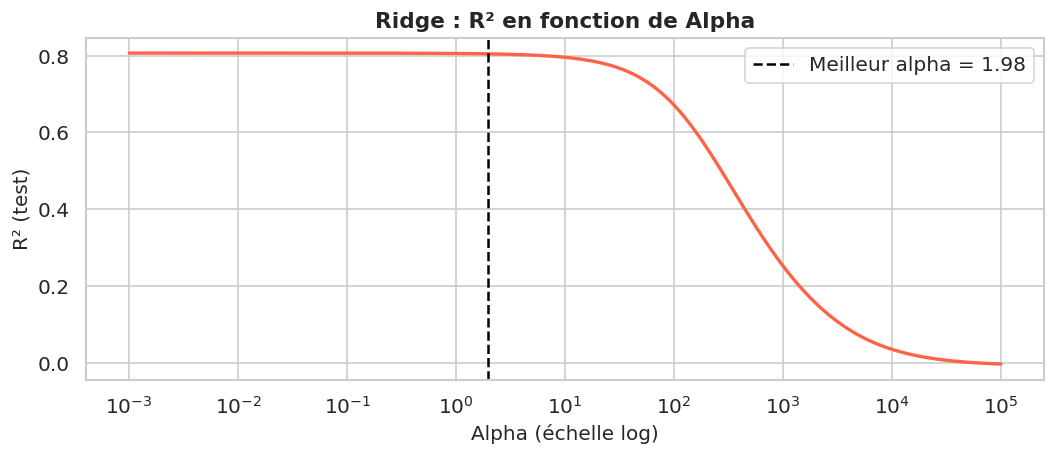

  MODÈLE 3 : Lasso Regression (L1)
  Meilleur alpha (LassoCV) : 26.4308
  RMSE train :     6,084.49   |   RMSE test :     5,993.51
  MAE  test  :     4,198.61   |   R²  test  :       0.8045
  R²   train :       0.7296   |   CV R² (5-fold) : 0.7260 ± 0.0251

--- Coefficients ---
         Feature  Coefficient
          smoker 22899.264542
             age  3467.051444
             bmi  1881.511413
        children   619.298484
region_southeast  -378.967338
region_southwest  -229.392299
             sex    -0.000000
region_northwest    -0.000000

 Features annulées par Lasso (coeff = 0) : ['sex', 'region_northwest']


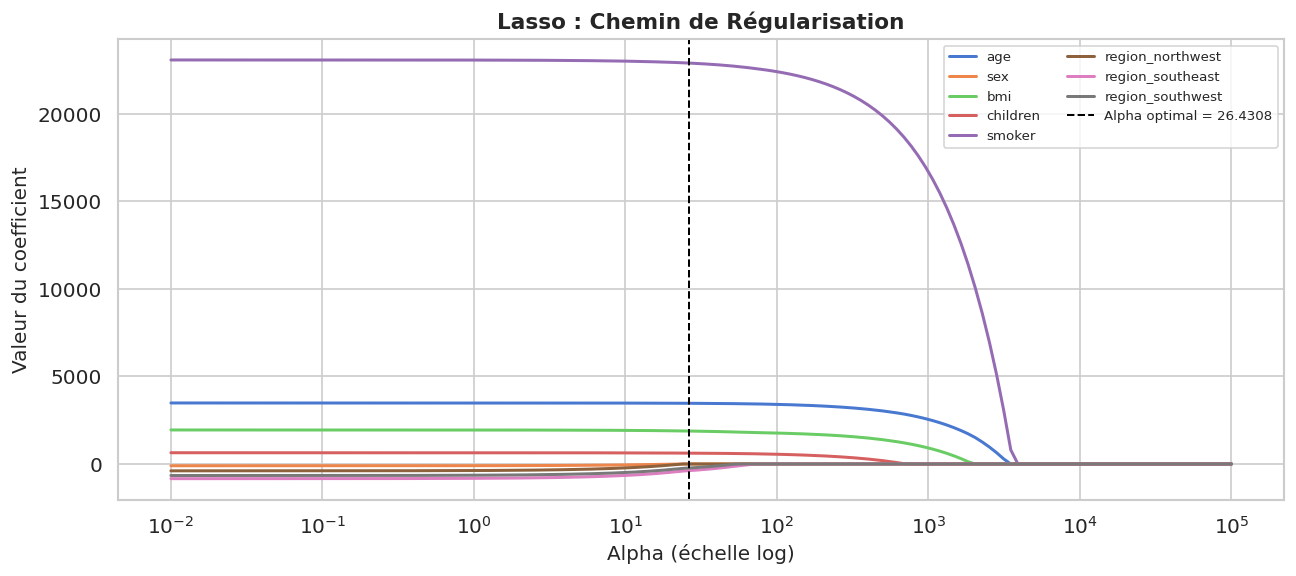

  MODÈLE 4 : ElasticNet (L1 + L2)
  Meilleur alpha    (ElasticNetCV) : 26.4308
  Meilleur l1_ratio (ElasticNetCV) : 1.00
  RMSE train :     6,084.49   |   RMSE test :     5,993.51
  MAE  test  :     4,198.61   |   R²  test  :       0.8045
  R²   train :       0.7296   |   CV R² (5-fold) : 0.7260 ± 0.0251

--- Coefficients ---
         Feature  Coefficient
          smoker 22899.264542
             age  3467.051444
             bmi  1881.511413
        children   619.298484
region_southeast  -378.967338
region_southwest  -229.392299
             sex    -0.000000
region_northwest    -0.000000
=== Tableau Comparatif des Coefficients ===
                  LinearRegression     Ridge     Lasso  ElasticNet
Feature                                                           
smoker                    23077.76  22808.25  22899.26    22899.26
age                        3484.65   3475.52   3467.05     3467.05
bmi                        1943.50   1934.22   1881.51     1881.51
region_southeast       

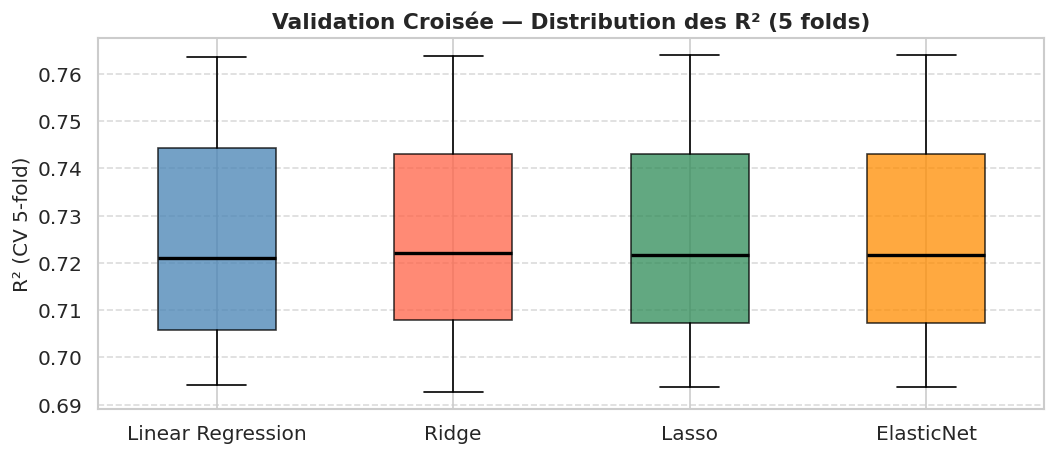

In [ ]:
#Fonctions Utilitaires
feature_names = list(X.columns)
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Calcule RMSE, MAE, R² train et test + CV score."""
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    rmse_train = np.sqrt(mean_squared_error(y_tr, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_te, y_pred_test))
    mae_test   = mean_absolute_error(y_te, y_pred_test)
    r2_train   = r2_score(y_tr, y_pred_train)
    r2_test    = r2_score(y_te, y_pred_test)

    # Cross-validation (5 folds, scoring=R²)
    cv_scores  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f'  RMSE train : {rmse_train:>12,.2f}   |   RMSE test : {rmse_test:>12,.2f}')
    print(f'  MAE  test  : {mae_test:>12,.2f}   |   R²  test  : {r2_test:>12.4f}')
    print(f'  R²   train : {r2_train:>12.4f}   |   CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    return {
        'Modèle': name,
        'RMSE Train': rmse_train, 'RMSE Test': rmse_test,
        'MAE Test': mae_test,
        'R² Train': r2_train, 'R² Test': r2_test,
        'CV R² Mean': cv_scores.mean(), 'CV R² Std': cv_scores.std(),
        'y_pred': y_pred_test
    }


def plot_coefficients(models_dict, feature_names):
    """Bar chart comparatif des coefficients pour tous les modèles."""
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)
    colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

    for ax, (name, model), color in zip(axes, models_dict.items(), colors):
        coefs = model.coef_
        sorted_idx = np.argsort(np.abs(coefs))[::-1]
        ax.barh(
            [feature_names[i] for i in sorted_idx],
            coefs[sorted_idx],
            color=color, edgecolor='white', alpha=0.85
        )
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Coefficient')

    plt.suptitle('Coefficients des Modèles de Régression', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('phase3_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

#6.1 Modèle 1 — Régression Linéaire (OLS)
print('=' * 55)
print('  MODÈLE 1 : Régression Linéaire (OLS)')
print('=' * 55)

lr = LinearRegression()
lr.fit(X_train, y_train)

results_lr = evaluate_model('Linear Regression', lr, X_train, y_train, X_test, y_test)

print('\n--- Coefficients ---')
coef_df_lr = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr.coef_})
coef_df_lr['|Coefficient|'] = coef_df_lr['Coefficient'].abs()
coef_df_lr = coef_df_lr.sort_values('|Coefficient|', ascending=False)
print(coef_df_lr.drop(columns='|Coefficient|').to_string(index=False))
print(f'\n  Intercept : {lr.intercept_:,.2f}')

#6.2 Modèle 2 — Ridge Regression (L2)
print('=' * 55)
print('  MODÈLE 2 : Ridge Regression (L2)')
print('=' * 55)

    # Recherche du meilleur alpha via RidgeCV (cross-validation interne)
alphas = np.logspace(-3, 5, 200)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f'  Meilleur alpha (RidgeCV) : {best_alpha_ridge:.4f}')

    # Modèle final avec le meilleur alpha
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

results_ridge = evaluate_model('Ridge', ridge, X_train, y_train, X_test, y_test)

print('\n--- Coefficients ---')
coef_df_ridge = pd.DataFrame({'Feature': feature_names, 'Coefficient': ridge.coef_})
coef_df_ridge['|Coefficient|'] = coef_df_ridge['Coefficient'].abs()
coef_df_ridge = coef_df_ridge.sort_values('|Coefficient|', ascending=False)
print(coef_df_ridge.drop(columns='|Coefficient|').to_string(index=False))

    # Courbe : R² en fonction de alpha (Ridge)
r2_ridge_alphas = []
for a in alphas:
    m = Ridge(alpha=a).fit(X_train, y_train)
    r2_ridge_alphas.append(r2_score(y_test, m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.semilogx(alphas, r2_ridge_alphas, color='tomato', linewidth=2)
plt.axvline(best_alpha_ridge, color='black', linestyle='--', label=f'Meilleur alpha = {best_alpha_ridge:.2f}')
plt.xlabel('Alpha (échelle log)', fontsize=12)
plt.ylabel('R² (test)', fontsize=12)
plt.title('Ridge : R² en fonction de Alpha', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('phase3_ridge_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

#6.3 Modèle 3 — Lasso Regression (L1)
print('=' * 55)
print('  MODÈLE 3 : Lasso Regression (L1)')
print('=' * 55)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f'  Meilleur alpha (LassoCV) : {best_alpha_lasso:.4f}')

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train, y_train)

results_lasso = evaluate_model('Lasso', lasso, X_train, y_train, X_test, y_test)

print('\n--- Coefficients ---')
coef_df_lasso = pd.DataFrame({'Feature': feature_names, 'Coefficient': lasso.coef_})
coef_df_lasso['|Coefficient|'] = coef_df_lasso['Coefficient'].abs()
coef_df_lasso = coef_df_lasso.sort_values('|Coefficient|', ascending=False)
print(coef_df_lasso.drop(columns='|Coefficient|').to_string(index=False))

zero_coef = coef_df_lasso[coef_df_lasso['Coefficient'] == 0]['Feature'].tolist()
if zero_coef:
    print(f'\n Features annulées par Lasso (coeff = 0) : {zero_coef}')
else:
    print('\n  Aucun coefficient mis à zéro par Lasso avec cet alpha optimal.')

# Chemin de régularisation Lasso
alphas_lasso_path = np.logspace(-2, 5, 150)
coefs_path = []
for a in alphas_lasso_path:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    coefs_path.append(m.coef_)

coefs_path = np.array(coefs_path)

plt.figure(figsize=(11, 5))
for i, fname in enumerate(feature_names):
    plt.semilogx(alphas_lasso_path, coefs_path[:, i], label=fname, linewidth=1.8)
plt.axvline(best_alpha_lasso, color='black', linestyle='--', linewidth=1.2, label=f'Alpha optimal = {best_alpha_lasso:.4f}')
plt.xlabel('Alpha (échelle log)', fontsize=12)
plt.ylabel('Valeur du coefficient', fontsize=12)
plt.title('Lasso : Chemin de Régularisation', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('phase3_lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

#6.4 Modèle 4 — ElasticNet (L1 + L2)
print('=' * 55)
print('  MODÈLE 4 : ElasticNet (L1 + L2)')
print('=' * 55)

l1_ratios = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]

enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    random_state=42
)
enet_cv.fit(X_train, y_train)

best_alpha_enet  = enet_cv.alpha_
best_l1_enet     = enet_cv.l1_ratio_
print(f'  Meilleur alpha    (ElasticNetCV) : {best_alpha_enet:.4f}')
print(f'  Meilleur l1_ratio (ElasticNetCV) : {best_l1_enet:.2f}')

enet = ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1_enet, max_iter=10000)
enet.fit(X_train, y_train)

results_enet = evaluate_model('ElasticNet', enet, X_train, y_train, X_test, y_test)

print('\n--- Coefficients ---')
coef_df_enet = pd.DataFrame({'Feature': feature_names, 'Coefficient': enet.coef_})
coef_df_enet['|Coefficient|'] = coef_df_enet['Coefficient'].abs()
coef_df_enet = coef_df_enet.sort_values('|Coefficient|', ascending=False)
print(coef_df_enet.drop(columns='|Coefficient|').to_string(index=False))


  #Les coefficients
coef_comparison = pd.DataFrame({
    'Feature'          : feature_names,
    'LinearRegression' : lr.coef_,
    'Ridge'            : ridge.coef_,
    'Lasso'            : lasso.coef_,
    'ElasticNet'       : enet.coef_
})

coef_comparison = coef_comparison.set_index('Feature')
coef_comparison['Max |Coeff|'] = coef_comparison.abs().max(axis=1)
coef_comparison = coef_comparison.sort_values('Max |Coeff|', ascending=False).drop(columns='Max |Coeff|')

print('=== Tableau Comparatif des Coefficients ===')
print(coef_comparison.round(2).to_string())

  #Validation Croisée
cv_results = {}
models_dict = {
    'Linear Regression': lr,
    'Ridge': ridge,
    'Lasso': lasso,
    'ElasticNet': enet
}
for name, model in models_dict.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:22s} → CV R² : {scores.mean():.4f} ± {scores.std():.4f}  | folds : {scores.round(4)}')

# Boxplot des scores CV
fig, ax = plt.subplots(figsize=(9, 4))
data_cv = [cv_results[k] for k in models_dict.keys()]
bp = ax.boxplot(data_cv, patch_artist=True, labels=list(models_dict.keys()),
                widths=0.5, medianprops={'color': 'black', 'linewidth': 2})

colors_cv = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('R² (CV 5-fold)', fontsize=12)
ax.set_title('Validation Croisée — Distribution des R² (5 folds)', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('phase3_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()



# **7. Phase 4 — Évaluation des Modèles**


 calcul des métriques pour chaque modèle
  Linear Regression
    RMSE      :     5,956.34 USD
    MAE       :     4,177.05 USD
    R² Test   :       0.8069
    R² Train  :       0.7299
    Adj. R²   :       0.8010
    MAPE      :       41.40 %

  Ridge
    RMSE      :     5,987.39 USD
    MAE       :     4,210.18 USD
    R² Test   :       0.8049
    R² Train  :       0.7298
    Adj. R²   :       0.7989
    MAPE      :       41.88 %

  Lasso
    RMSE      :     5,993.51 USD
    MAE       :     4,198.61 USD
    R² Test   :       0.8045
    R² Train  :       0.7296
    Adj. R²   :       0.7985
    MAPE      :       41.78 %

  ElasticNet
    RMSE      :     5,993.51 USD
    MAE       :     4,198.61 USD
    R² Test   :       0.8045
    R² Train  :       0.7296
    Adj. R²   :       0.7985
    MAPE      :       41.78 %


 Tableau récapitulatif des métriques
=== Tableau Récapitulatif des Métriques ===
                      RMSE      MAE  R² Test  R² Train  Adj. R²  MAPE (%)
Modèle           

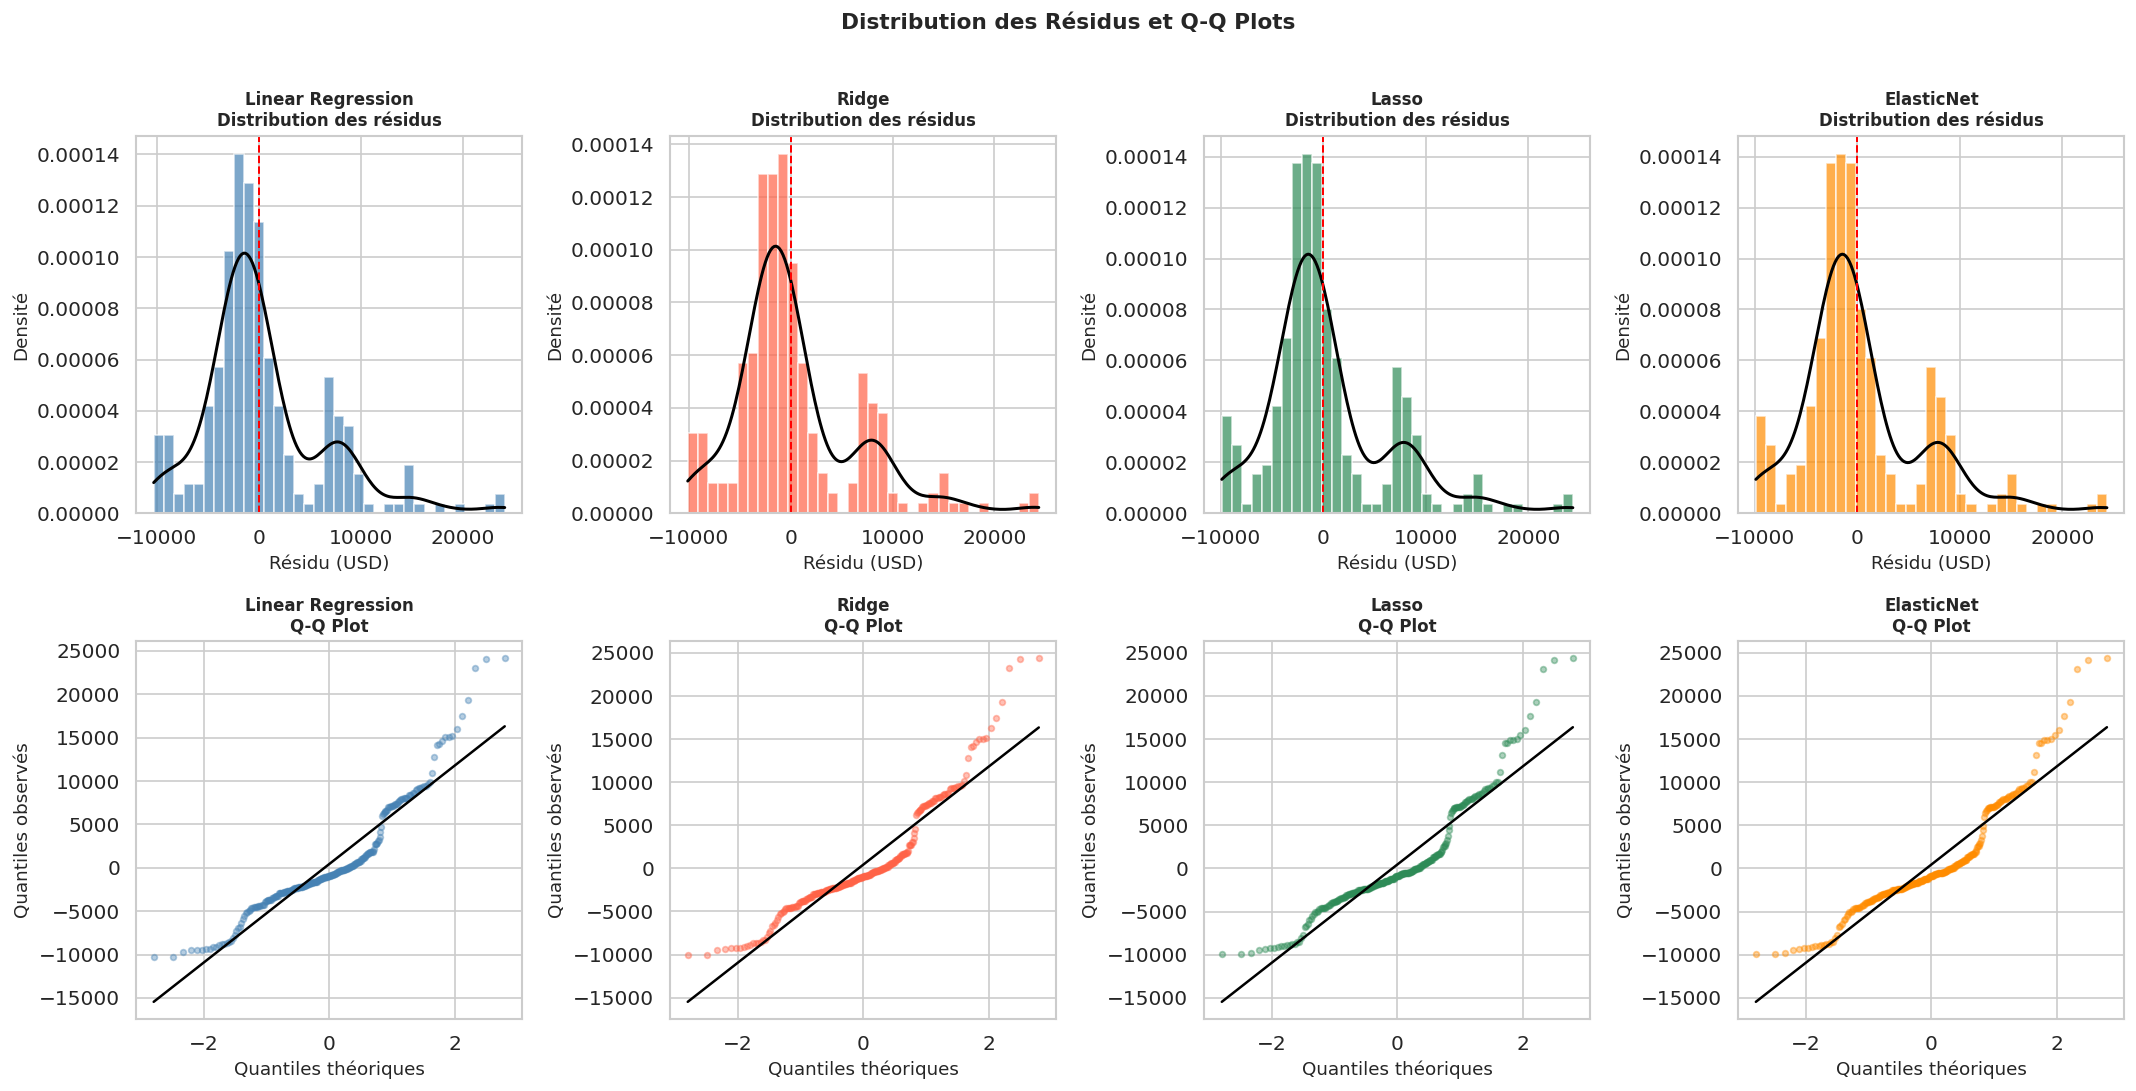

=== Statistiques des Résidus ===
                   Moyenne      Std       Min       Max  Skewness  Kurtosis  Shapiro p
Modèle                                                                                
Linear Regression   425.26  5941.14 -10314.51  24111.22    1.2356    2.2900        0.0
Ridge               433.21  5971.70 -10089.45  24350.36    1.2691    2.2787        0.0
Lasso               452.55  5976.40  -9877.14  24342.35    1.2646    2.2743        0.0
ElasticNet          452.55  5976.40  -9877.14  24342.35    1.2646    2.2743        0.0

  Shapiro p > 0.05 → normalité non rejetée
  Shapiro p < 0.05 → normalité rejetée (attendu avec des outliers)

 Valeurs Réelles vs Prédites


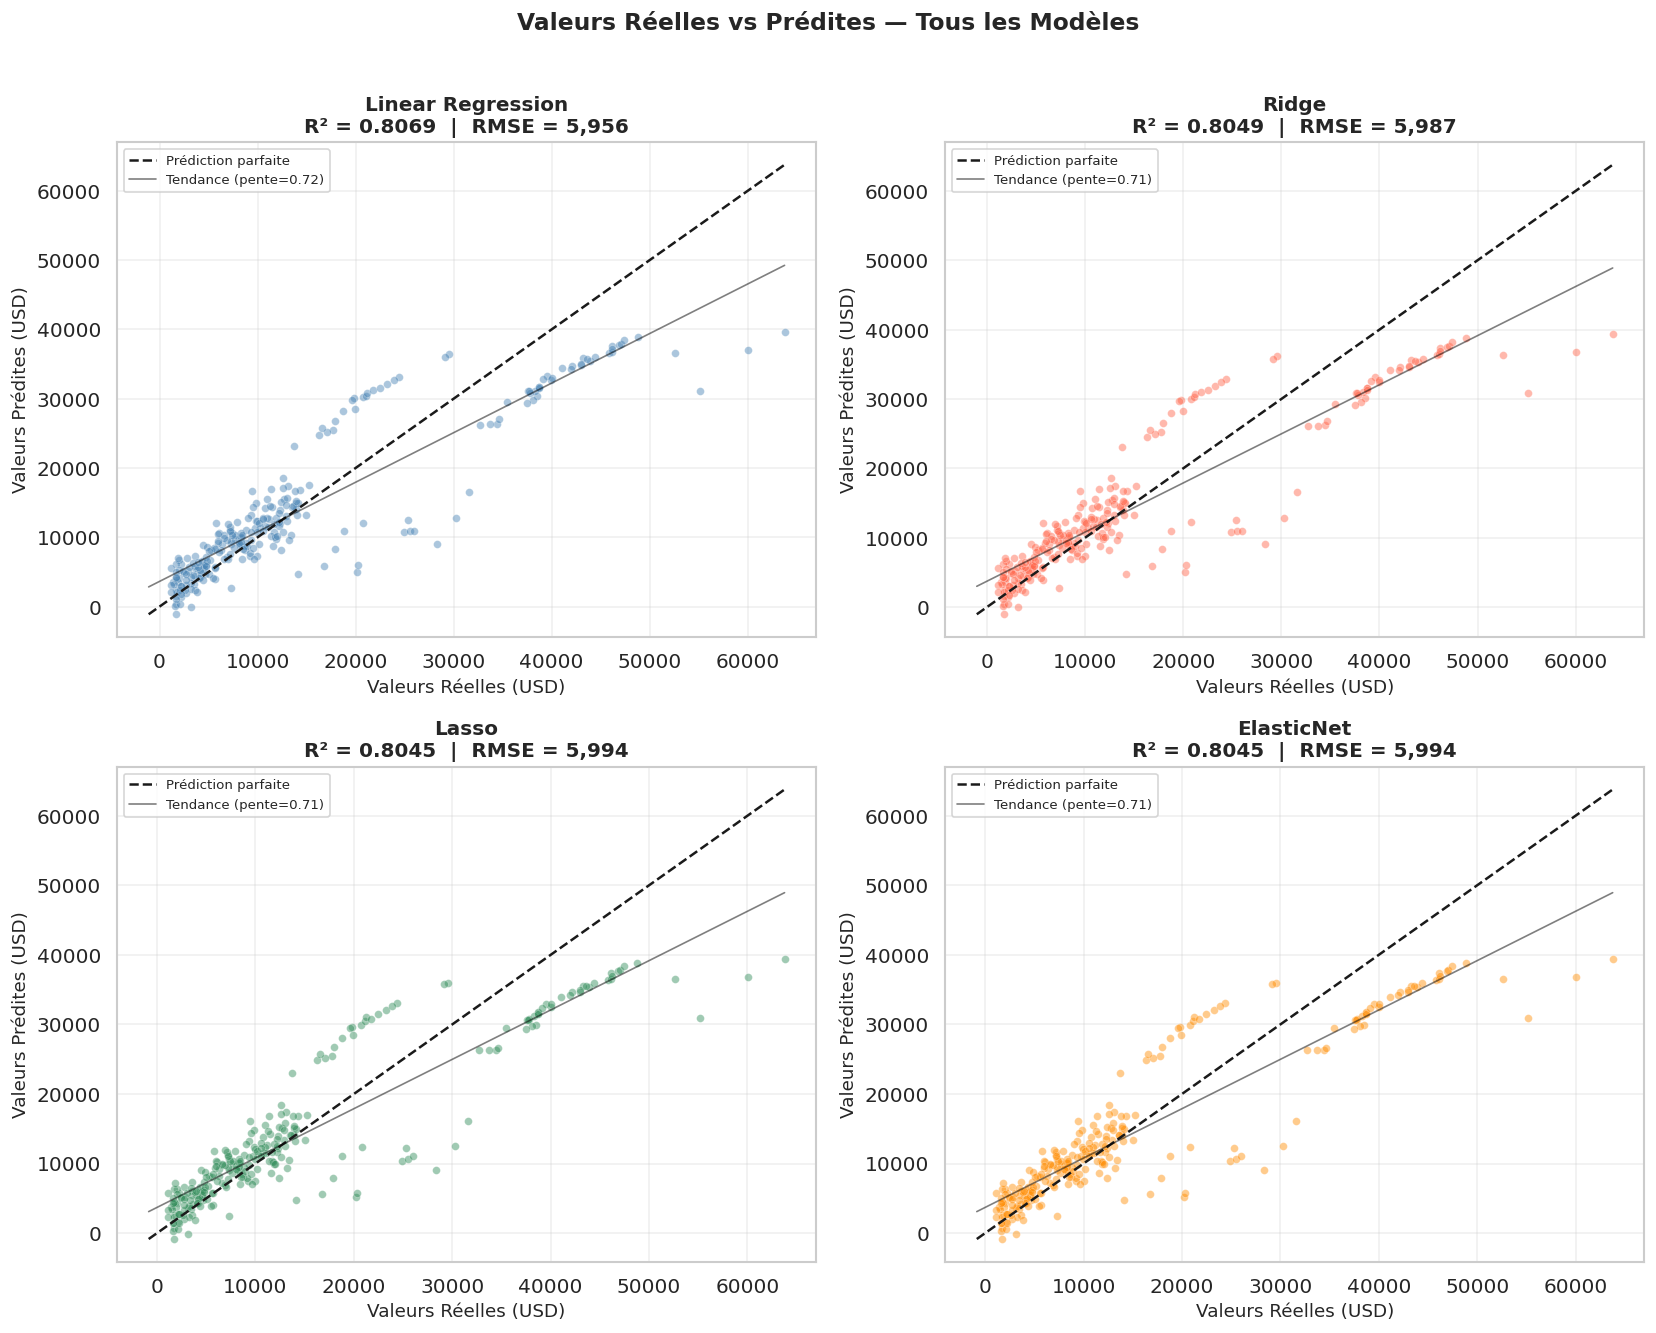

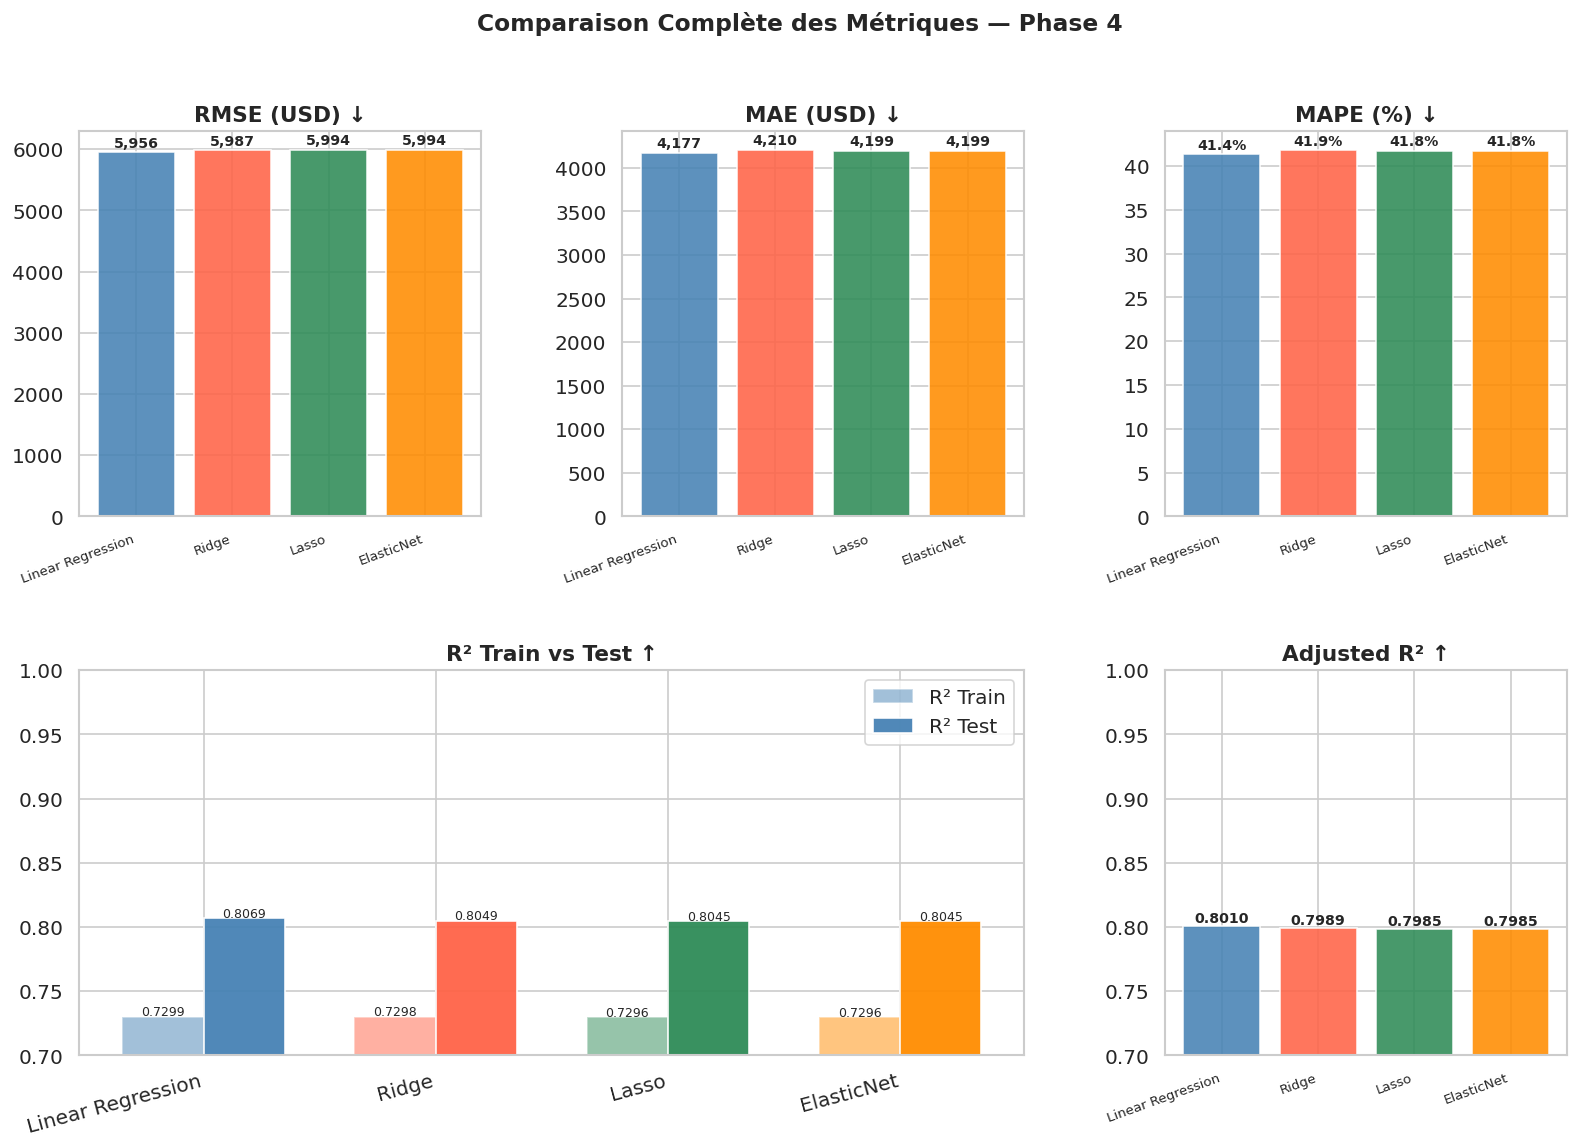

=== Classement par Score Composite (rang moyen) ===
                   Rang RMSE  Rang MAE  Rang R²  Rang Adj. R²  Rang MAPE  Score moyen
Modèle                                                                               
Linear Regression        1.0       1.0      1.0           1.0        1.0          1.0
Ridge                    2.0       4.0      2.0           2.0        4.0          2.8
Lasso                    3.5       2.5      3.5           3.5        2.5          3.1
ElasticNet               3.5       2.5      3.5           3.5        2.5          3.1

 MEILLEUR MODÈLE : Linear Regression
   RMSE    : 5,956.34 USD
   MAE     : 4,177.05 USD
   R² Test : 0.8069
   Adj. R² : 0.8010
   MAPE    : 41.40 %


In [ ]:
from scipy import stats
import matplotlib.gridspec as gridspec
#7.1 Fonctions de Métriques
def adjusted_r2(r2, n, p):
    """R² ajusté : pénalise les modèles ayant trop de features."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — évite la division par zéro."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_all_metrics(name, model, X_te, y_te, X_tr, y_tr):
    n, p = len(y_te), X_te.shape[1]
    y_pred    = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)

    rmse     = np.sqrt(mean_squared_error(y_te, y_pred))
    mae      = mean_absolute_error(y_te, y_pred)
    r2       = r2_score(y_te, y_pred)
    r2_tr    = r2_score(y_tr, y_pred_tr)
    adj_r2   = adjusted_r2(r2, n, p)
    mape_val = mape(y_te.values, y_pred)

    return {
        'Modèle'   : name,
        'RMSE'     : round(rmse, 2),
        'MAE'      : round(mae, 2),
        'R² Test'  : round(r2, 4),
        'R² Train' : round(r2_tr, 4),
        'Adj. R²'  : round(adj_r2, 4),
        'MAPE (%)' : round(mape_val, 2),
        'y_pred'   : y_pred,
        'résidus'  : y_te.values - y_pred
    }

  #Calcul des Métriques pour Chaque Modèle
print('\n calcul des métriques pour chaque modèle')
models = {
    'Linear Regression': lr,
    'Ridge'            : ridge,
    'Lasso'            : lasso,
    'ElasticNet'       : enet
}

colors_models = ['steelblue', 'tomato', 'seagreen', 'darkorange']

all_results = []
for name, model in models.items():
    res = compute_all_metrics(name, model, X_test, y_test, X_train, y_train)
    all_results.append(res)
    print(f'  {name}')
    print(f'    RMSE      : {res["RMSE"]:>12,.2f} USD')
    print(f'    MAE       : {res["MAE"]:>12,.2f} USD')
    print(f'    R² Test   : {res["R² Test"]:>12.4f}')
    print(f'    R² Train  : {res["R² Train"]:>12.4f}')
    print(f'    Adj. R²   : {res["Adj. R²"]:>12.4f}')
    print(f'    MAPE      : {res["MAPE (%)"]:>11.2f} %')
    print()

#7.2 Tableau Récapitulatif Comparatif
print('\n Tableau récapitulatif des métriques')
metrics_cols = ['Modèle', 'RMSE', 'MAE', 'R² Test', 'R² Train', 'Adj. R²', 'MAPE (%)']
summary_df = pd.DataFrame([{k: r[k] for k in metrics_cols} for r in all_results])
summary_df = summary_df.set_index('Modèle')

print('=== Tableau Récapitulatif des Métriques ===')
print(summary_df.to_string())

print(f'\n Meilleur R²   : {summary_df["R² Test"].idxmax()}')
print(f' Meilleur RMSE : {summary_df["RMSE"].idxmin()}')
print(f' Meilleur MAE  : {summary_df["MAE"].idxmin()}')

#7.3 Analyse des Résidus
print('\n Analyse des résidus')
# --- Distribution des résidus + Q-Q Plot ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (res, color) in enumerate(zip(all_results, colors_models)):
    residuals = res['résidus']

    # Histogramme + KDE
    ax = axes[0, col]
    ax.hist(residuals, bins=35, color=color, alpha=0.7, edgecolor='white', density=True)
    kde_x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(kde_x, stats.gaussian_kde(residuals)(kde_x), color='black', linewidth=1.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_title(f'{res["Modèle"]}\nDistribution des résidus', fontsize=10, fontweight='bold')
    ax.set_xlabel('Résidu (USD)')
    ax.set_ylabel('Densité')

    # Q-Q Plot
    ax2 = axes[1, col]
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax2.scatter(osm, osr, alpha=0.4, s=12, color=color)
    ax2.plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.5)
    ax2.set_title(f'{res["Modèle"]}\nQ-Q Plot', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Quantiles théoriques')
    ax2.set_ylabel('Quantiles observés')

plt.suptitle('Distribution des Résidus et Q-Q Plots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
# --- Statistiques descriptives des résidus ---
residus_stats = []
for res in all_results:
    r = res['résidus']
    _, p_sw = stats.shapiro(r[:200])
    residus_stats.append({
        'Modèle'   : res['Modèle'],
        'Moyenne'  : round(r.mean(), 2),
        'Std'      : round(r.std(), 2),
        'Min'      : round(r.min(), 2),
        'Max'      : round(r.max(), 2),
        'Skewness' : round(stats.skew(r), 4),
        'Kurtosis' : round(stats.kurtosis(r), 4),
        'Shapiro p': round(p_sw, 4)
    })

print('=== Statistiques des Résidus ===')
print(pd.DataFrame(residus_stats).set_index('Modèle').to_string())
print('\n  Shapiro p > 0.05 → normalité non rejetée')
print('  Shapiro p < 0.05 → normalité rejetée (attendu avec des outliers)')

  # Valeurs Réelles vs Prédites
print('\n Valeurs Réelles vs Prédites')
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, res, color in zip(axes, all_results, colors_models):
    y_pred = res['y_pred']
    y_true = y_test.values

    ax.scatter(y_true, y_pred, alpha=0.45, s=22, color=color, edgecolors='white', linewidth=0.3)

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Prédiction parfaite')

    m, b = np.polyfit(y_true, y_pred, 1)
    ax.plot(np.array(lims), m * np.array(lims) + b, color='black',
            linewidth=1, linestyle='-', alpha=0.5, label=f'Tendance (pente={m:.2f})')

    ax.set_xlabel('Valeurs Réelles (USD)', fontsize=11)
    ax.set_ylabel('Valeurs Prédites (USD)', fontsize=11)
    ax.set_title(f'{res["Modèle"]}\nR² = {res["R² Test"]:.4f}  |  RMSE = {res["RMSE"]:,.0f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Valeurs Réelles vs Prédites — Tous les Modèles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  #Comparaison visuelle complète des modèles
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
model_names = summary_df.index.tolist()
x = np.arange(len(model_names))

# RMSE
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(model_names, summary_df['RMSE'], color=colors_models, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, summary_df['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{v:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax1.set_title('RMSE (USD) ↓', fontweight='bold')
ax1.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)

# MAE
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(model_names, summary_df['MAE'], color=colors_models, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, summary_df['MAE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{v:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.set_title('MAE (USD) ↓', fontweight='bold')
ax2.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)

# MAPE
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(model_names, summary_df['MAPE (%)'], color=colors_models, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, summary_df['MAPE (%)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax3.set_title('MAPE (%) ↓', fontweight='bold')
ax3.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)

# R² Train vs Test
ax4 = fig.add_subplot(gs[1, 0:2])
w = 0.35
ax4.bar(x - w/2, summary_df['R² Train'], w, label='R² Train', color=colors_models, alpha=0.5, edgecolor='white')
ax4.bar(x + w/2, summary_df['R² Test'],  w, label='R² Test',  color=colors_models, alpha=0.95, edgecolor='white')
for i, (tr, te) in enumerate(zip(summary_df['R² Train'], summary_df['R² Test'])):
    ax4.text(i - w/2, tr + 0.001, f'{tr:.4f}', ha='center', fontsize=7.5)
    ax4.text(i + w/2, te + 0.001, f'{te:.4f}', ha='center', fontsize=7.5)
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=15, ha='right')
ax4.set_title('R² Train vs Test ↑', fontweight='bold')
ax4.set_ylim(0.7, 1.0)
ax4.legend()

# Adj. R²
ax5 = fig.add_subplot(gs[1, 2])
bars = ax5.bar(model_names, summary_df['Adj. R²'], color=colors_models, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, summary_df['Adj. R²']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax5.set_title('Adjusted R² ↑', fontweight='bold')
ax5.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
ax5.set_ylim(0.7, 1.0)

plt.suptitle('Comparaison Complète des Métriques — Phase 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  #Identification du Meilleur Modèle
ranking = pd.DataFrame(index=summary_df.index)
ranking['Rang RMSE']    = summary_df['RMSE'].rank(ascending=True)
ranking['Rang MAE']     = summary_df['MAE'].rank(ascending=True)
ranking['Rang R²']      = summary_df['R² Test'].rank(ascending=False)
ranking['Rang Adj. R²'] = summary_df['Adj. R²'].rank(ascending=False)
ranking['Rang MAPE']    = summary_df['MAPE (%)'].rank(ascending=True)
ranking['Score moyen']  = ranking.mean(axis=1)
ranking = ranking.sort_values('Score moyen')

print('=== Classement par Score Composite (rang moyen) ===')
print(ranking.round(2).to_string())

best = ranking.index[0]
print(f'\n MEILLEUR MODÈLE : {best}')
print(f'   RMSE    : {summary_df.loc[best, "RMSE"]:,.2f} USD')
print(f'   MAE     : {summary_df.loc[best, "MAE"]:,.2f} USD')
print(f'   R² Test : {summary_df.loc[best, "R² Test"]:.4f}')
print(f'   Adj. R² : {summary_df.loc[best, "Adj. R²"]:.4f}')
print(f'   MAPE    : {summary_df.loc[best, "MAPE (%)"]:.2f} %')

# **8. Phase 5 — Sélection de Features (Feature Selection)**


In [ ]:
from sklearn.feature_selection import RFE

#8.1 Backward Elimination (statsmodels)
print('Backward elimination')
def backward_elimination(X, y, seuil=0.05):
    features = list(X.columns)
    iteration = 1
    while True:
        X_sm = sm.add_constant(X[features])
        model = sm.OLS(y, X_sm).fit()
        pvalues = model.pvalues.drop('const')
        max_pval = pvalues.max()
        if max_pval > seuil:
            worst = pvalues.idxmax()
            print(f'  Itération {iteration} — Suppression : {worst:20s} (p={max_pval:.4f})')
            features.remove(worst)
            iteration += 1
        else:
            break
    print(f'\n Features retenues ({len(features)}) : {features}')
    return features, model

print('=== Backward Elimination (seuil p-value = 0.05) ===')
selected_features, final_ols = backward_elimination(X_train, y_train)

  # P-values du modèle final
print('=== P-values du modèle final ===')
print(final_ols.pvalues.drop('const').sort_values().to_string())

#8.2 RFE — Recursive Feature Elimination
print('\nRFE')
rfe = RFE(estimator=LinearRegression(), n_features_to_select=len(selected_features))
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    'Feature' : feature_names,
    'Sélectionnée': rfe.support_,
    'Rang'    : rfe.ranking_
}).sort_values('Rang')

print(rfe_df.to_string(index=False))
rfe_features = rfe_df[rfe_df['Sélectionnée']]['Feature'].tolist()
print(f'\n Features RFE sélectionnées : {rfe_features}')

#8.3 Analyse des Coefficients Lasso
print('\nAnalyse des Coefficients Lasso')
lasso_coef = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Coefficients Lasso ===')
print(lasso_coef.to_string(index=False))

lasso_zero    = lasso_coef[lasso_coef['Coefficient'] == 0]['Feature'].tolist()
lasso_nonzero = lasso_coef[lasso_coef['Coefficient'] != 0]['Feature'].tolist()
print(f'\n  Annulées (coeff=0) : {lasso_zero if lasso_zero else "Aucune"}')
print(f'  Retenues : {lasso_nonzero}')





Backward elimination
=== Backward Elimination (seuil p-value = 0.05) ===
  Itération 1 — Suppression : sex                  (p=0.7871)
  Itération 2 — Suppression : region_northwest     (p=0.4656)
  Itération 3 — Suppression : region_southwest     (p=0.3264)
  Itération 4 — Suppression : region_southeast     (p=0.2859)

 Features retenues (4) : ['age', 'bmi', 'children', 'smoker']
=== P-values du modèle final ===
smoker      2.835161e-277
age          1.948662e-66
bmi          7.801252e-22
children     6.148677e-04

RFE
         Feature  Sélectionnée  Rang
             age          True     1
             bmi          True     1
        children          True     1
          smoker          True     1
region_southeast         False     2
region_southwest         False     3
region_northwest         False     4
             sex         False     5

 Features RFE sélectionnées : ['age', 'bmi', 'children', 'smoker']

Analyse des Coefficients Lasso
=== Coefficients Lasso ===
         Featu

# **9. Phase 6 — Comparaison : Tous les Features vs Features Sélectionnées**

Ré-entraînement avec les Features Sélectionnées
 Modèles ré-entraînés sur 4 features : ['age', 'bmi', 'children', 'smoker']

 Calcul des métriques — Comparaison
=== Tableau Comparatif : All Features vs Selected Features ===
                   RMSE (All)  RMSE (Sel)  MAE (All)  MAE (Sel)  R² (All)  R² (Sel)  Adj.R² (All)  Adj.R² (Sel)
Modèle                                                                                                         
Linear Regression     5956.34     5992.88    4177.05    4198.59    0.8069    0.8046        0.8010        0.8016
Ridge                 5987.39     6022.73    4210.18    4231.84    0.8049    0.8026        0.7989        0.7996
Lasso                 5993.51     6014.32    4198.61    4213.43    0.8045    0.8032        0.7985        0.8002
ElasticNet            5993.51     6014.32    4198.61    4213.43    0.8045    0.8032        0.7985        0.8002

 Visualisation Comparative


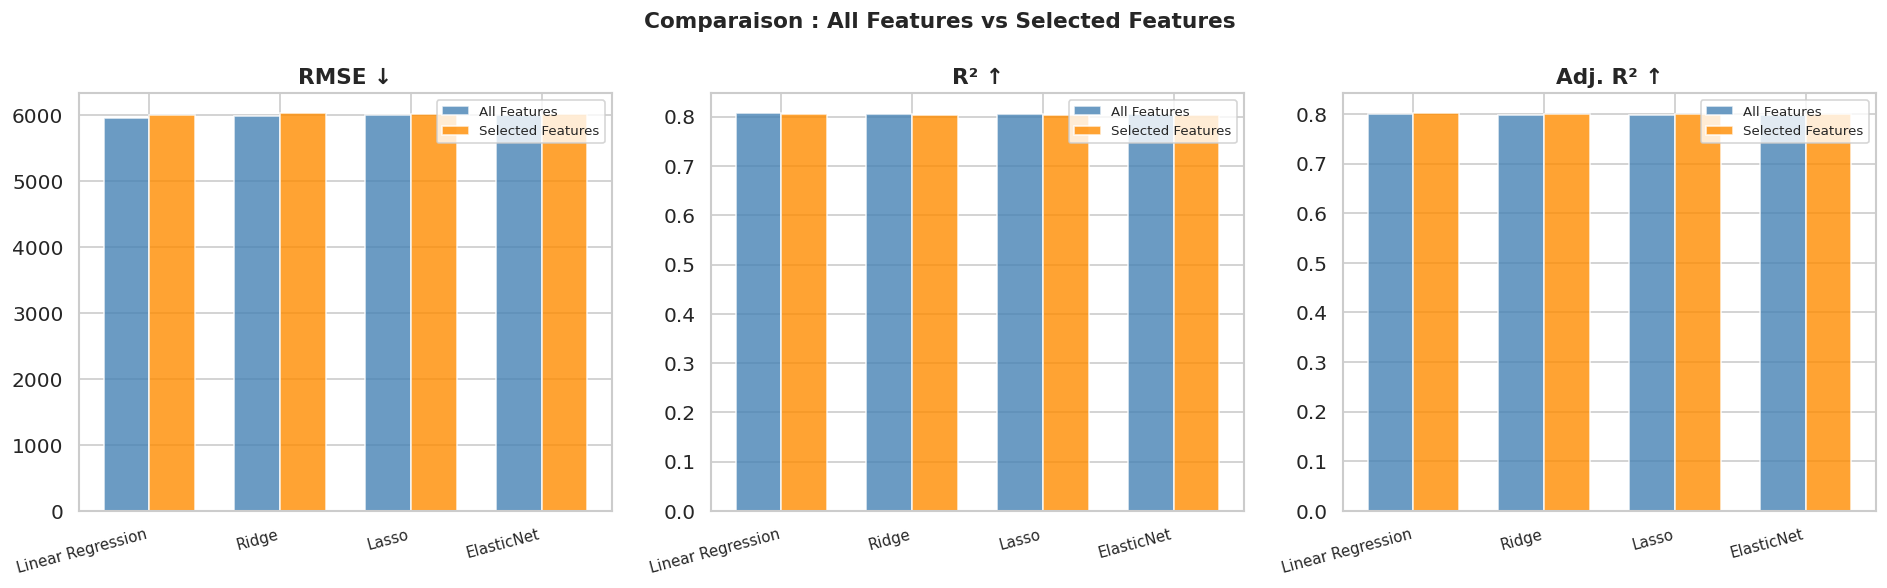


 Analyse de l'Impact
=== Impact de la Sélection de Features ===
  Linear Regression      → ΔR² = -0.0023   ΔRMSE = +36.54 USD
  Ridge                  → ΔR² = -0.0023   ΔRMSE = +35.34 USD
  Lasso                  → ΔR² = -0.0013   ΔRMSE = +20.81 USD
  ElasticNet             → ΔR² = -0.0013   ΔRMSE = +20.81 USD

  Δ > 0 pour R²   → amélioration  |  Δ < 0 pour R²   → dégradation
  Δ < 0 pour RMSE → amélioration  |  Δ > 0 pour RMSE → dégradation


In [ ]:
  #9.1 Ré-entraînement avec les Features Sélectionnées
print('Ré-entraînement avec les Features Sélectionnées')
final_selected = selected_features
X_train_sel = X_train[final_selected]
X_test_sel  = X_test[final_selected]

models_sel = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=ridge.alpha),
    'Lasso'            : Lasso(alpha=lasso.alpha, max_iter=10000),
    'ElasticNet'       : ElasticNet(alpha=enet.alpha, l1_ratio=enet.l1_ratio, max_iter=10000)
}

for name, model in models_sel.items():
    model.fit(X_train_sel, y_train)

print(f' Modèles ré-entraînés sur {len(final_selected)} features : {final_selected}')

  #9.2 Calcul des Métriques — Comparaison
print('\n Calcul des métriques — Comparaison')
def get_metrics(model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    r2     = r2_score(y_te, y_pred)
    n, p   = len(y_te), X_te.shape[1]
    return {
        'RMSE'   : round(np.sqrt(mean_squared_error(y_te, y_pred)), 2),
        'MAE'    : round(mean_absolute_error(y_te, y_pred), 2),
        'R²'     : round(r2, 4),
        'Adj. R²': round(1 - (1 - r2) * (n - 1) / (n - p - 1), 4)
    }

rows = []
for name in models.keys():
    m_all = models[name]
    m_sel = models_sel[name]
    all_m = get_metrics(m_all, X_train, y_train, X_test, y_test)
    sel_m = get_metrics(m_sel, X_train_sel, y_train, X_test_sel, y_test)
    rows.append({
        'Modèle'         : name,
        'RMSE (All)'     : all_m['RMSE'],   'RMSE (Sel)'    : sel_m['RMSE'],
        'MAE (All)'      : all_m['MAE'],    'MAE (Sel)'     : sel_m['MAE'],
        'R² (All)'       : all_m['R²'],     'R² (Sel)'      : sel_m['R²'],
        'Adj.R² (All)'   : all_m['Adj. R²'],'Adj.R² (Sel)'  : sel_m['Adj. R²']
    })

comp_df = pd.DataFrame(rows).set_index('Modèle')
print('=== Tableau Comparatif : All Features vs Selected Features ===')
print(comp_df.to_string())

  #9.3 Visualisation Comparative
print('\n Visualisation Comparative')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = comp_df.index.tolist()
x = np.arange(len(model_names))
w = 0.35

for ax, metric, title, asc in zip(
    axes,
    [('RMSE (All)', 'RMSE (Sel)'), ('R² (All)', 'R² (Sel)'), ('Adj.R² (All)', 'Adj.R² (Sel)')],
    ['RMSE ↓', 'R² ↑', 'Adj. R² ↑'],
    [True, False, False]
):
    col_all, col_sel = metric
    bars1 = ax.bar(x - w/2, comp_df[col_all], w, label='All Features',      color='steelblue', alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + w/2, comp_df[col_sel], w, label='Selected Features', color='darkorange', alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Comparaison : All Features vs Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
  #9.4 Analyse de l'Impact
print('\n Analyse de l\'Impact')
print('=== Impact de la Sélection de Features ===')
for name in comp_df.index:
    delta_r2   = comp_df.loc[name, 'R² (Sel)']   - comp_df.loc[name, 'R² (All)']
    delta_rmse = comp_df.loc[name, 'RMSE (Sel)']  - comp_df.loc[name, 'RMSE (All)']
    sign_r2    = '+' if delta_r2   >= 0 else ''
    sign_rmse  = '+' if delta_rmse >= 0 else ''
    print(f'  {name:22s} → ΔR² = {sign_r2}{delta_r2:.4f}   ΔRMSE = {sign_rmse}{delta_rmse:,.2f} USD')

print('\n  Δ > 0 pour R²   → amélioration  |  Δ < 0 pour R²   → dégradation')
print('  Δ < 0 pour RMSE → amélioration  |  Δ > 0 pour RMSE → dégradation')





# **10. Phase 7 — Conclusion**

7.1 Résumé des Résultats




  BILAN FINAL DU PROJET
  Dataset          : medical-charges.csv (1 338 obs.)
  Features initiales : 8
  Features retenues  : 4 (['age', 'bmi', 'children', 'smoker'])

   Meilleur modèle : Linear Regression
     RMSE    : 5,956.34 USD
     MAE     : 4,177.05 USD
     R²      : 0.8069
     Adj. R² : 0.8010


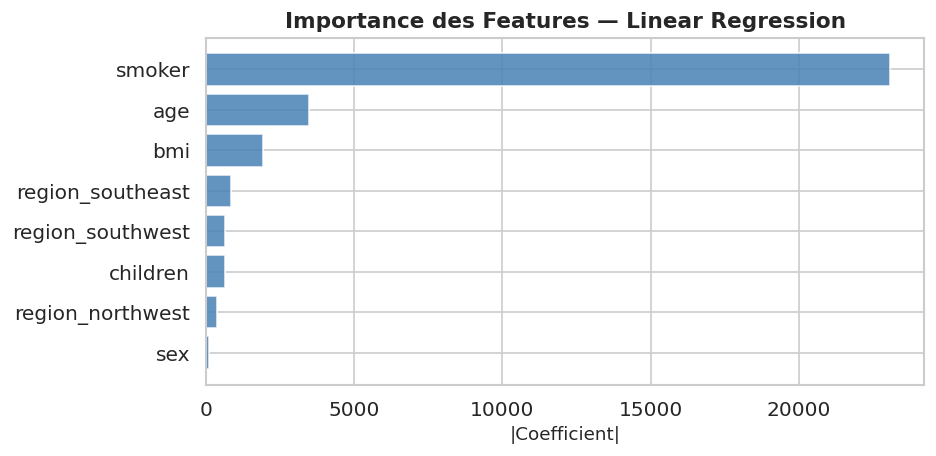

In [ ]:

# Meilleur modèle (All Features)
best_name = summary_df['R² Test'].idxmax()
best      = summary_df.loc[best_name]

print('=' * 55)
print('  BILAN FINAL DU PROJET')
print('=' * 55)
print(f'  Dataset          : medical-charges.csv (1 338 obs.)')
print(f'  Features initiales : {len(feature_names)}')
print(f'  Features retenues  : {len(final_selected)} ({final_selected})')
print()
print(f'   Meilleur modèle : {best_name}')
print(f'     RMSE    : {best["RMSE"]:,.2f} USD')
print(f'     MAE     : {best["MAE"]:,.2f} USD')
print(f'     R²      : {best["R² Test"]:.4f}')
print(f'     Adj. R² : {best["Adj. R²"]:.4f}')
print('=' * 55)

# Importance des features (coefficients du meilleur modèle)
best_model = models[best_name]
importance = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : np.abs(best_model.coef_)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance['Feature'], importance['Importance'],
         color='steelblue', edgecolor='white', alpha=0.85)
plt.xlabel('|Coefficient|')
plt.title(f'Importance des Features — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()



  10.2 Observations clés

**1. Impact du statut fumeur (smoker) :**

C'est la variable la plus influente dans tous les modèles. Les fumeurs ont des charges médicales significativement plus élevées que les non-fumeurs, toutes choses égales par ailleurs.

**2. Rôle de l'âge et de l'IMC :**

L'age et le bmi ont tous deux un impact positif sur les charges. Un IMC élevé combiné au tabagisme génère une interaction non-linéaire que les modèles linéaires peinent à capturer parfaitement.

**3. Variables secondaires :**

Le nombre d'enfants, le sexe et la région ont un impact faible mais statistiquement significatif.

7.3 Limites du projet

| Limite | Description |
|--------|-------------|
| **Taille du dataset** | 1 338 observations est faible pour généraliser sur toute une population |
| **Hypothèse de linéarité** | Les relations bmi × smoker sont non-linéaires — mal capturées par OLS |
| **Variables manquantes** | Des facteurs comme les antécédents médicaux, la profession ou le revenu sont absents |
| **Hétéroscédasticité** | La variance des résidus croît avec les charges élevées — hypothèse OLS violée |


7.4 Perspectives d'Amélioration

| Piste | Description |
|-------|-------------|
| **Transformation log(charges)** | Réduire l'hétéroscédasticité et améliorer la normalité des résidus |
| **Feature Engineering** | Créer une interaction `bmi × smoker` pour capturer l'effet combiné |
| **Modèles non-linéaires** | Decision Tree, Random Forest, XGBoost — mieux adaptés aux non-linéarités |
| **Données supplémentaires** | Antécédents médicaux, historique de remboursements, mode de vie |